In [1]:
import yfinance as yf
import pandas as pd
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ===== 1. Make repo importable =====
# 假设 notebook 在: CS50-analysis/tests/Harmonic_pattern_demo.ipynb
REPO_ROOT = Path.cwd().resolve().parents[0]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT =", REPO_ROOT)

from stock_analysis.config import SLD_WINDOW_CONFIG
from stock_analysis.tools.candlestick_utils import (
    add_candlestick_features,
    safe_ratio,
)

REPO_ROOT = C:\Users\17866\OneDrive\桌面\Ltq\2026a\data5703\project\work\current_work\CS50-analysis


## Export Data

In [2]:
# 1. Define tickers and settings
tickers = ["AAPL", "TSLA", "NVDA", "MSFT", "AMZN"]

period = "max"      # ✅ 最大历史数据（核心）
interval = "1m"     # ✅ 日线（适合 harmonic）

# 2. Download OHLC data
data = yf.download(
    tickers=tickers,
    period=period,
    interval=interval,
    group_by="ticker",
    auto_adjust=False,
    progress=False,
    threads=True
)

print("Data type:", type(data))
print("Shape:", data.shape)
print("Columns:")
print(data.columns)

# 3. Keep only OHLC columns
ohlc_data = data.loc[:, (slice(None), ['Open', 'High', 'Low', 'Close'])].copy()

print("\nOHLC-only shape:", ohlc_data.shape)

# 4. Convert wide MultiIndex to long format
long_list = []

for ticker in tickers:
    try:
        df_ticker = ohlc_data[ticker].copy().reset_index()

        # ✅ 兼容 Date / Datetime 命名差异
        time_col = df_ticker.columns[0]
        df_ticker = df_ticker.rename(columns={time_col: "Datetime"})

        df_ticker["Ticker"] = ticker

        df_ticker = df_ticker[["Datetime", "Ticker", "Open", "High", "Low", "Close"]]

        df_ticker = df_ticker.dropna(subset=["Open", "High", "Low", "Close"]).copy()

        long_list.append(df_ticker)

    except Exception as e:
        print(f"{ticker}: failed to process -> {e}")

# 5. Merge all tickers
df_long = pd.concat(long_list, ignore_index=True)

# 6. Sort data
df_long = df_long.sort_values(["Ticker", "Datetime"]).reset_index(drop=True)

# 7. Basic inspection
print("\nLong-format data:")
print(df_long.head())

print("\nShape:", df_long.shape)

print("\nRows per ticker:")
print(df_long["Ticker"].value_counts())

# 8. Export
#output_file = "stock_1min_OHLC_long.csv"
#df_long.to_csv(output_file, index=False)
#print(f"\nSaved file: {output_file}")
df_long.head()

Data type: <class 'pandas.core.frame.DataFrame'>
Shape: (2338, 30)
Columns:
MultiIndex([('TSLA',      'Open'),
            ('TSLA',      'High'),
            ('TSLA',       'Low'),
            ('TSLA',     'Close'),
            ('TSLA', 'Adj Close'),
            ('TSLA',    'Volume'),
            ('MSFT',      'Open'),
            ('MSFT',      'High'),
            ('MSFT',       'Low'),
            ('MSFT',     'Close'),
            ('MSFT', 'Adj Close'),
            ('MSFT',    'Volume'),
            ('NVDA',      'Open'),
            ('NVDA',      'High'),
            ('NVDA',       'Low'),
            ('NVDA',     'Close'),
            ('NVDA', 'Adj Close'),
            ('NVDA',    'Volume'),
            ('AAPL',      'Open'),
            ('AAPL',      'High'),
            ('AAPL',       'Low'),
            ('AAPL',     'Close'),
            ('AAPL', 'Adj Close'),
            ('AAPL',    'Volume'),
            ('AMZN',      'Open'),
            ('AMZN',      'High'),
            ('

Price,Datetime,Ticker,Open,High,Low,Close
0,2026-03-26 13:30:00+00:00,AAPL,251.994995,252.470001,250.774994,251.539993
1,2026-03-26 13:31:00+00:00,AAPL,251.550003,251.550003,251.039993,251.299896
2,2026-03-26 13:32:00+00:00,AAPL,251.279999,251.660004,251.070007,251.550003
3,2026-03-26 13:33:00+00:00,AAPL,251.559998,251.710007,251.320007,251.395004
4,2026-03-26 13:34:00+00:00,AAPL,251.380005,251.794998,251.309998,251.752594


## Test and Visualization

In [3]:
def scan_candlestick_for_ticker(
    df_ticker: pd.DataFrame,
    pattern,
    window_size: int = 1,
) -> pd.DataFrame:
    results = []

    df_ticker = df_ticker.sort_values("Datetime").reset_index(drop=True).copy()

    empty_cols = [
        "Ticker", "Datetime", "Pattern", "Category",
        "Confidence", "WindowStartIdx", "WindowEndIdx"
    ]

    if len(df_ticker) < window_size:
        return pd.DataFrame(columns=empty_cols)

    for end_idx in range(window_size, len(df_ticker) + 1):
        start_idx = end_idx - window_size
        window_df = df_ticker.iloc[start_idx:end_idx].reset_index(drop=True)

        event_time = df_ticker.iloc[end_idx - 1]["Datetime"]
        ticker = df_ticker.iloc[end_idx - 1]["Ticker"]

        result = pattern.execute(window_df)

        if result.confirmed:
            results.append({
                "Ticker": ticker,
                "Datetime": event_time,
                "Pattern": pattern.__class__.__name__,
                "Category": pattern.category,
                "Confidence": result.confidence,
                "WindowStartIdx": start_idx,
                "WindowEndIdx": end_idx - 1,
            })

    if not results:
        return pd.DataFrame(columns=empty_cols)

    return pd.DataFrame(results)

In [4]:
def scan_all_candlestick_patterns(
    df_all: pd.DataFrame,
    pattern,
    window_size: int = 1,
) -> pd.DataFrame:
    all_results = []

    print("Using window_size =", window_size)
    print("Scanning tickers:", df_all["Ticker"].unique().tolist())

    for ticker in df_all["Ticker"].unique():
        df_ticker = df_all[df_all["Ticker"] == ticker].copy()

        results_ticker = scan_candlestick_for_ticker(
            df_ticker=df_ticker,
            pattern=pattern,
            window_size=window_size,
        )

        all_results.append(results_ticker)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

In [5]:
def plot_candlestick_window(
    df_plot: pd.DataFrame,
    highlight_idx: int = None,
    title: str = "Candlestick Pattern Window",
):
    df_plot = df_plot.copy().reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(14, 6))

    x = np.arange(len(df_plot))
    candle_width = 0.6

    for i, row in df_plot.iterrows():
        open_ = row["Open"]
        high_ = row["High"]
        low_ = row["Low"]
        close_ = row["Close"]

        # wick
        ax.plot([i, i], [low_, high_], linewidth=1.2)

        # body
        body_low = min(open_, close_)
        body_height = abs(close_ - open_)

        # 避免十字星实体太小完全看不见
        display_body_height = max(body_height, 0.001)

        rect = Rectangle(
            (i - candle_width / 2, body_low),
            candle_width,
            display_body_height,
            fill=False,
            linewidth=1.5
        )
        ax.add_patch(rect)

    # 高亮目标K线
    if highlight_idx is not None:
        row = df_plot.iloc[highlight_idx]
        ax.scatter(
            highlight_idx,
            row["Close"],
            s=140,
            zorder=5,
            label="Detected Doji"
        )
        ax.axvline(highlight_idx, linestyle="--", linewidth=1)
        ax.text(
            highlight_idx,
            row["High"],
            "Doji",
            fontsize=11,
            fontweight="bold",
            ha="center",
            va="bottom"
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [str(pd.to_datetime(dt))[:16] for dt in df_plot["Datetime"]],
        rotation=45,
        ha="right"
    )

    ax.set_title(title)
    ax.set_xlabel("Datetime")
    ax.set_ylabel("Price")
    ax.grid(True, linestyle="--", alpha=0.4)

    if highlight_idx is not None:
        ax.legend()

    plt.tight_layout()
    plt.show()

Doji pattern

In [6]:
from stock_analysis.candlestick_patterns.Doji_Candlestick import DojiCandlestickPattern

In [7]:
def explain_doji_candle(df_window: pd.DataFrame) -> dict:
    df_feat = add_candlestick_features(df_window)
    c = df_feat.iloc[-1]

    body = c["body"]
    range_ = c["range"]
    upper_wick = c["upper_wick"]
    lower_wick = c["lower_wick"]

    body_ratio = safe_ratio(body, range_)
    wick_total_ratio = safe_ratio(upper_wick + lower_wick, range_)
    wick_diff_ratio = safe_ratio(abs(upper_wick - lower_wick), range_)

    shape_ok = (
        range_ > 0
        and body_ratio <= 0.1
        and upper_wick > 0
        and lower_wick > 0
        and wick_total_ratio >= 0.75
    )

    return {
        "Datetime": c["Datetime"] if "Datetime" in c.index else None,
        "Open": c["Open"],
        "High": c["High"],
        "Low": c["Low"],
        "Close": c["Close"],
        "body": body,
        "range": range_,
        "upper_wick": upper_wick,
        "lower_wick": lower_wick,
        "body_ratio": body_ratio,
        "wick_total_ratio": wick_total_ratio,
        "wick_diff_ratio": wick_diff_ratio,
        "direction": c["direction"],
        "shape_ok": shape_ok,
    }

In [8]:
def extract_pattern_context(
    df_all: pd.DataFrame,
    ticker: str,
    event_idx: int,
    left_context: int = 8,
    right_context: int = 3,
) -> tuple[pd.DataFrame, int]:
    df_ticker = (
        df_all[df_all["Ticker"] == ticker]
        .sort_values("Datetime")
        .reset_index(drop=True)
        .copy()
    )

    plot_start = max(0, event_idx - left_context)
    plot_end = min(len(df_ticker), event_idx + right_context + 1)

    plot_df = df_ticker.iloc[plot_start:plot_end].reset_index(drop=True)

    # 返回“事件K线在plot_df中的相对位置”
    local_event_idx = event_idx - plot_start

    return plot_df, local_event_idx

In [9]:
pattern = DojiCandlestickPattern()
window_size = 1

doji_results = scan_all_candlestick_patterns(
    df_all=df_long,
    pattern=pattern,
    window_size=window_size,
)

print("Total detected Doji patterns:", len(doji_results))

if doji_results.empty:
    print("No Doji patterns detected.")
else:
    print("\nCounts by ticker:")
    print(doji_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        doji_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 1
Scanning tickers: ['AAPL', 'AMZN', 'MSFT', 'NVDA', 'TSLA']
Total detected Doji patterns: 1078

Counts by ticker:
Ticker
TSLA    248
NVDA    221
MSFT    217
AMZN    209
AAPL    183
Name: count, dtype: int64

Top 20 by confidence:


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
11,AAPL,2026-03-26 15:15:00+00:00,DojiCandlestickPattern,candlestick,100.0,105,105
12,AAPL,2026-03-26 15:22:00+00:00,DojiCandlestickPattern,candlestick,100.0,112,112
45,AAPL,2026-03-27 16:50:00+00:00,DojiCandlestickPattern,candlestick,100.0,588,588
56,AAPL,2026-03-27 18:02:00+00:00,DojiCandlestickPattern,candlestick,100.0,660,660
62,AAPL,2026-03-27 19:35:00+00:00,DojiCandlestickPattern,candlestick,100.0,753,753
72,AAPL,2026-03-30 14:30:00+00:00,DojiCandlestickPattern,candlestick,100.0,838,838
85,AAPL,2026-03-30 17:55:00+00:00,DojiCandlestickPattern,candlestick,100.0,1043,1043
89,AAPL,2026-03-30 19:25:00+00:00,DojiCandlestickPattern,candlestick,100.0,1133,1133
90,AAPL,2026-03-30 19:26:00+00:00,DojiCandlestickPattern,candlestick,100.0,1134,1134
92,AAPL,2026-03-30 19:31:00+00:00,DojiCandlestickPattern,candlestick,100.0,1139,1139


In [10]:
if doji_results.empty:
    print("No Doji patterns found, cannot select top candidate.")
else:
    top_doji = (
        doji_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Doji candidate:")
    print(top_doji)

    top_ticker = top_doji["Ticker"]
    top_event_idx = int(top_doji["WindowEndIdx"])  # doji就是最后一根
    top_time = top_doji["Datetime"]

    print("\nSelected ticker:", top_ticker)
    print("Event index:", top_event_idx)
    print("Event time:", top_time)

Top Doji candidate:
Ticker                                 AAPL
Datetime          2026-03-26 15:15:00+00:00
Pattern              DojiCandlestickPattern
Category                        candlestick
Confidence                            100.0
WindowStartIdx                          105
WindowEndIdx                            105
Name: 11, dtype: object

Selected ticker: AAPL
Event index: 105
Event time: 2026-03-26 15:15:00+00:00


In [11]:
plot_df, local_event_idx = extract_pattern_context(
    df_all=df_long,
    ticker=top_ticker,
    event_idx=top_event_idx,
    left_context=8,
    right_context=3,
)

print("Plot window shape:", plot_df.shape)
display(plot_df.head())
display(plot_df.tail())

Plot window shape: (12, 6)


Price,Datetime,Ticker,Open,High,Low,Close
0,2026-03-26 15:07:00+00:00,AAPL,256.660004,256.700012,256.429993,256.549988
1,2026-03-26 15:08:00+00:00,AAPL,256.540009,256.600006,256.410004,256.480011
2,2026-03-26 15:09:00+00:00,AAPL,256.459991,256.549988,256.429993,256.441986
3,2026-03-26 15:10:00+00:00,AAPL,256.454987,256.600006,256.440094,256.480011
4,2026-03-26 15:11:00+00:00,AAPL,256.484985,256.489990,256.334991,256.369995


Price,Datetime,Ticker,Open,High,Low,Close
7,2026-03-26 15:14:00+00:00,AAPL,256.320007,256.380005,256.160004,256.160004
8,2026-03-26 15:15:00+00:00,AAPL,256.200012,256.279999,256.140015,256.204987
9,2026-03-26 15:16:00+00:00,AAPL,256.214996,256.244995,255.940002,256.005005
10,2026-03-26 15:17:00+00:00,AAPL,256.019989,256.105011,255.990005,256.050110
11,2026-03-26 15:18:00+00:00,AAPL,256.059998,256.140015,255.990005,256.005005


In [12]:
target_candle_df = plot_df.iloc[[local_event_idx]].copy().reset_index(drop=True)

doji_explanation = explain_doji_candle(target_candle_df)

print("Extracted Doji explanation:")
for k, v in doji_explanation.items():
    print(f"{k}: {v}")

Extracted Doji explanation:
Datetime: 2026-03-26 15:15:00+00:00
Open: 256.20001220703125
High: 256.2799987792969
Low: 256.1400146484375
Close: 256.2049865722656
body: 0.004974365234375
range: 0.139984130859375
upper_wick: 0.07501220703125
lower_wick: 0.05999755859375
body_ratio: 0.0355352081970787
wick_total_ratio: 0.9644647918029213
wick_diff_ratio: 0.10725964682799215
direction: bullish
shape_ok: True


In [13]:
doji_explanation_df = pd.DataFrame([doji_explanation])
display(doji_explanation_df)

,Datetime,Open,High,Low,Close,body,range,upper_wick,lower_wick,body_ratio,wick_total_ratio,wick_diff_ratio,direction,shape_ok
0,2026-03-26 15:15:00+00:00,256.200012,256.279999,256.140015,256.204987,0.004974,0.139984,0.075012,0.059998,0.035535,0.964465,0.10726,bullish,True


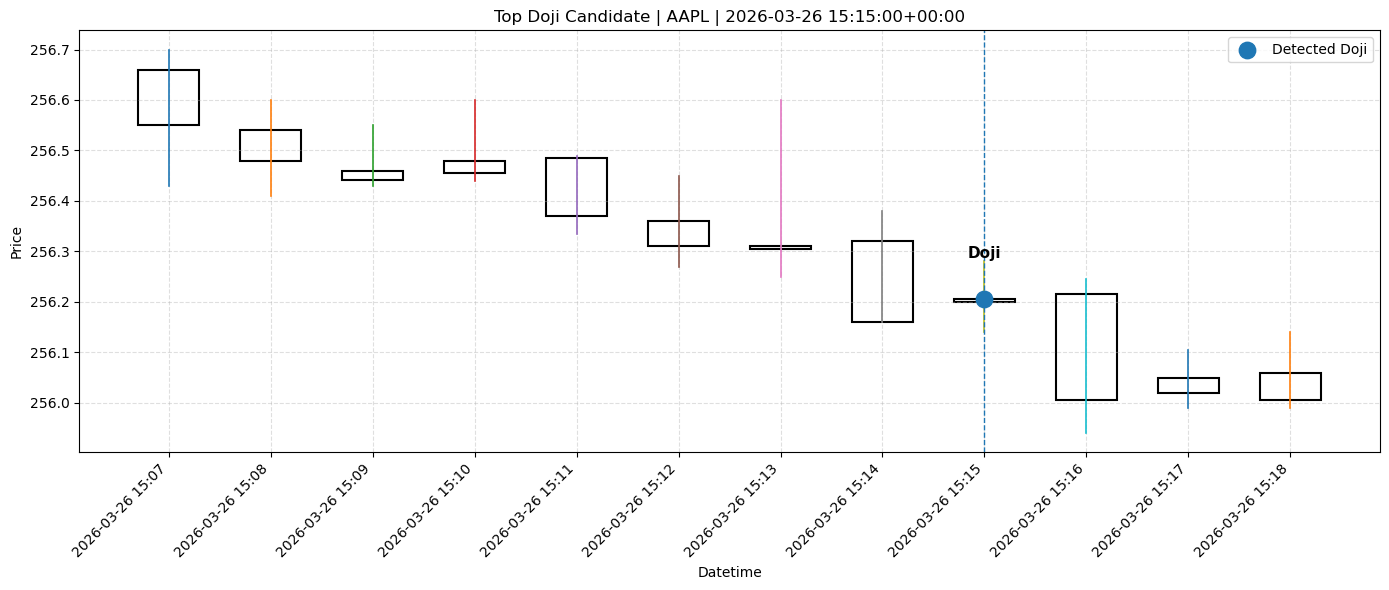

In [14]:
plot_candlestick_window(
    df_plot=plot_df,
    highlight_idx=local_event_idx,
    title=f"Top Doji Candidate | {top_ticker} | {top_time}"
)

Hammer

In [15]:
from stock_analysis.candlestick_patterns.Hammer_Candlestick import HammerCandlestickPattern
from stock_analysis.tools.candlestick_utils import (
    add_candlestick_features,
    safe_ratio,
    body_bottom_ratio,
)

In [16]:
def plot_candlestick_window(
    df_plot: pd.DataFrame,
    highlight_idx: int = None,
    title: str = "Candlestick Pattern Window",
    pattern_label: str = "Pattern"
):
    df_plot = df_plot.copy().reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(14, 6))

    x = np.arange(len(df_plot))
    candle_width = 0.6

    for i, row in df_plot.iterrows():
        open_ = row["Open"]
        high_ = row["High"]
        low_ = row["Low"]
        close_ = row["Close"]

        # wick
        ax.plot([i, i], [low_, high_], linewidth=1.2)

        # body
        body_low = min(open_, close_)
        body_height = abs(close_ - open_)

        # 避免实体过小看不见
        display_body_height = max(body_height, 0.001)

        rect = Rectangle(
            (i - candle_width / 2, body_low),
            candle_width,
            display_body_height,
            fill=False,
            linewidth=1.5
        )
        ax.add_patch(rect)

    if highlight_idx is not None:
        row = df_plot.iloc[highlight_idx]
        ax.scatter(
            highlight_idx,
            row["Close"],
            s=140,
            zorder=5,
            label=f"Detected {pattern_label}"
        )
        ax.axvline(highlight_idx, linestyle="--", linewidth=1)
        ax.text(
            highlight_idx,
            row["High"],
            pattern_label,
            fontsize=11,
            fontweight="bold",
            ha="center",
            va="bottom"
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [str(pd.to_datetime(dt))[:16] for dt in df_plot["Datetime"]],
        rotation=45,
        ha="right"
    )

    ax.set_title(title)
    ax.set_xlabel("Datetime")
    ax.set_ylabel("Price")
    ax.grid(True, linestyle="--", alpha=0.4)

    if highlight_idx is not None:
        ax.legend()

    plt.tight_layout()
    plt.show()

In [17]:
def explain_hammer_candle(df_window: pd.DataFrame) -> dict:
    df_feat = add_candlestick_features(df_window)
    c = df_feat.iloc[-1]

    body = c["body"]
    range_ = c["range"]
    upper_wick = c["upper_wick"]
    lower_wick = c["lower_wick"]

    body_ratio = safe_ratio(body, range_)
    lower_body_ratio = safe_ratio(lower_wick, max(body, 1e-9))
    upper_body_ratio = safe_ratio(upper_wick, max(body, 1e-9))
    upper_range_ratio = safe_ratio(upper_wick, range_)
    lower_range_ratio = safe_ratio(lower_wick, range_)
    body_low_pos = body_bottom_ratio(c)

    shape_ok = (
        body_ratio <= 0.35
        and lower_body_ratio >= 2.2
        and upper_body_ratio <= 0.5
        and body_low_pos >= 0.6
    )

    return {
        "Datetime": c["Datetime"] if "Datetime" in c.index else None,
        "Open": c["Open"],
        "High": c["High"],
        "Low": c["Low"],
        "Close": c["Close"],
        "body": body,
        "range": range_,
        "upper_wick": upper_wick,
        "lower_wick": lower_wick,
        "body_ratio": body_ratio,
        "lower_body_ratio": lower_body_ratio,
        "upper_body_ratio": upper_body_ratio,
        "lower_range_ratio": lower_range_ratio,
        "upper_range_ratio": upper_range_ratio,
        "body_low_pos": body_low_pos,
        "direction": c["direction"],
        "shape_ok": shape_ok,
    }

In [18]:
pattern = HammerCandlestickPattern()
window_size = 1

hammer_results = scan_all_candlestick_patterns(
    df_all=df_long,
    pattern=pattern,
    window_size=window_size,
)

print("Total detected Hammer patterns:", len(hammer_results))

if hammer_results.empty:
    print("No Hammer patterns detected.")
else:
    print("\nCounts by ticker:")
    print(hammer_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        hammer_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

HammerCandlestickPattern returned invalid data: 1 validation error for PatternResult
confidence
  Input should be less than or equal to 100 [type=less_than_equal, input_value=110, input_type=int]
    For further information visit https://errors.pydantic.dev/2.12/v/less_than_equal
HammerCandlestickPattern returned invalid data: 1 validation error for PatternResult
confidence
  Input should be less than or equal to 100 [type=less_than_equal, input_value=110, input_type=int]
    For further information visit https://errors.pydantic.dev/2.12/v/less_than_equal


Using window_size = 1
Scanning tickers: ['AAPL', 'AMZN', 'MSFT', 'NVDA', 'TSLA']


HammerCandlestickPattern returned invalid data: 1 validation error for PatternResult
confidence
  Input should be less than or equal to 100 [type=less_than_equal, input_value=110, input_type=int]
    For further information visit https://errors.pydantic.dev/2.12/v/less_than_equal
HammerCandlestickPattern returned invalid data: 1 validation error for PatternResult
confidence
  Input should be less than or equal to 100 [type=less_than_equal, input_value=105, input_type=int]
    For further information visit https://errors.pydantic.dev/2.12/v/less_than_equal
HammerCandlestickPattern returned invalid data: 1 validation error for PatternResult
confidence
  Input should be less than or equal to 100 [type=less_than_equal, input_value=105, input_type=int]
    For further information visit https://errors.pydantic.dev/2.12/v/less_than_equal
HammerCandlestickPattern returned invalid data: 1 validation error for PatternResult
confidence
  Input should be less than or equal to 100 [type=less_than_e

Total detected Hammer patterns: 170

Counts by ticker:
Ticker
MSFT    45
AAPL    33
TSLA    32
NVDA    31
AMZN    29
Name: count, dtype: int64

Top 20 by confidence:


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
13,AAPL,2026-03-27 19:09:00+00:00,HammerCandlestickPattern,candlestick,100.0,727,727
18,AAPL,2026-03-30 18:53:00+00:00,HammerCandlestickPattern,candlestick,100.0,1101,1101
22,AAPL,2026-03-31 15:07:00+00:00,HammerCandlestickPattern,candlestick,100.0,1265,1265
24,AAPL,2026-04-01 15:33:00+00:00,HammerCandlestickPattern,candlestick,100.0,1681,1681
25,AAPL,2026-04-01 17:52:00+00:00,HammerCandlestickPattern,candlestick,100.0,1820,1820
34,AMZN,2026-03-26 14:11:00+00:00,HammerCandlestickPattern,candlestick,100.0,41,41
41,AMZN,2026-03-27 16:40:00+00:00,HammerCandlestickPattern,candlestick,100.0,578,578
43,AMZN,2026-03-27 18:10:00+00:00,HammerCandlestickPattern,candlestick,100.0,668,668
45,AMZN,2026-03-30 16:36:00+00:00,HammerCandlestickPattern,candlestick,100.0,964,964
57,AMZN,2026-04-01 17:52:00+00:00,HammerCandlestickPattern,candlestick,100.0,1820,1820


In [19]:
if hammer_results.empty:
    print("No Hammer patterns found, cannot select top candidate.")
else:
    top_hammer = (
        hammer_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Hammer candidate:")
    print(top_hammer)

    top_ticker = top_hammer["Ticker"]
    top_event_idx = int(top_hammer["WindowEndIdx"])
    top_time = top_hammer["Datetime"]

    print("\nSelected ticker:", top_ticker)
    print("Event index:", top_event_idx)
    print("Event time:", top_time)

Top Hammer candidate:
Ticker                                 AAPL
Datetime          2026-03-27 19:09:00+00:00
Pattern            HammerCandlestickPattern
Category                        candlestick
Confidence                            100.0
WindowStartIdx                          727
WindowEndIdx                            727
Name: 13, dtype: object

Selected ticker: AAPL
Event index: 727
Event time: 2026-03-27 19:09:00+00:00


In [20]:
plot_df, local_event_idx = extract_pattern_context(
    df_all=df_long,
    ticker=top_ticker,
    event_idx=top_event_idx,
    left_context=8,
    right_context=3,
)

print("Plot window shape:", plot_df.shape)
display(plot_df.head())
display(plot_df.tail())

Plot window shape: (12, 6)


Price,Datetime,Ticker,Open,High,Low,Close
0,2026-03-27 19:01:00+00:00,AAPL,248.714996,248.770004,248.559998,248.660004
1,2026-03-27 19:02:00+00:00,AAPL,248.660004,248.970001,248.660004,248.860001
2,2026-03-27 19:03:00+00:00,AAPL,248.860001,248.860001,248.630005,248.725006
3,2026-03-27 19:04:00+00:00,AAPL,248.729996,248.729996,248.589996,248.634995
4,2026-03-27 19:05:00+00:00,AAPL,248.649994,248.705002,248.529999,248.705002


Price,Datetime,Ticker,Open,High,Low,Close
7,2026-03-27 19:08:00+00:00,AAPL,248.550003,248.550003,248.360107,248.445007
8,2026-03-27 19:09:00+00:00,AAPL,248.449997,248.449997,248.360001,248.429993
9,2026-03-27 19:10:00+00:00,AAPL,248.429993,248.449997,248.330002,248.449997
10,2026-03-27 19:11:00+00:00,AAPL,248.449997,248.699997,248.414993,248.654999
11,2026-03-27 19:12:00+00:00,AAPL,248.654999,249.080002,248.654999,248.960007


In [21]:
target_candle_df = plot_df.iloc[[local_event_idx]].copy().reset_index(drop=True)

hammer_explanation = explain_hammer_candle(target_candle_df)

print("Extracted Hammer explanation:")
for k, v in hammer_explanation.items():
    print(f"{k}: {v}")

Extracted Hammer explanation:
Datetime: 2026-03-27 19:09:00+00:00
Open: 248.4499969482422
High: 248.4499969482422
Low: 248.36000061035156
Close: 248.42999267578125
body: 0.0200042724609375
range: 0.089996337890625
upper_wick: 0.0
lower_wick: 0.0699920654296875
body_ratio: 0.22227873855544253
lower_body_ratio: 3.4988558352402745
upper_body_ratio: 0.0
lower_range_ratio: 0.7777212614445574
upper_range_ratio: 0.0
body_low_pos: 0.7777212614445574
direction: bearish
shape_ok: True


In [22]:
hammer_explanation_df = pd.DataFrame([hammer_explanation])
display(hammer_explanation_df)

,Datetime,Open,High,Low,Close,body,range,upper_wick,lower_wick,body_ratio,lower_body_ratio,upper_body_ratio,lower_range_ratio,upper_range_ratio,body_low_pos,direction,shape_ok
0,2026-03-27 19:09:00+00:00,248.449997,248.449997,248.360001,248.429993,0.020004,0.089996,0.0,0.069992,0.222279,3.498856,0.0,0.777721,0.0,0.777721,bearish,True


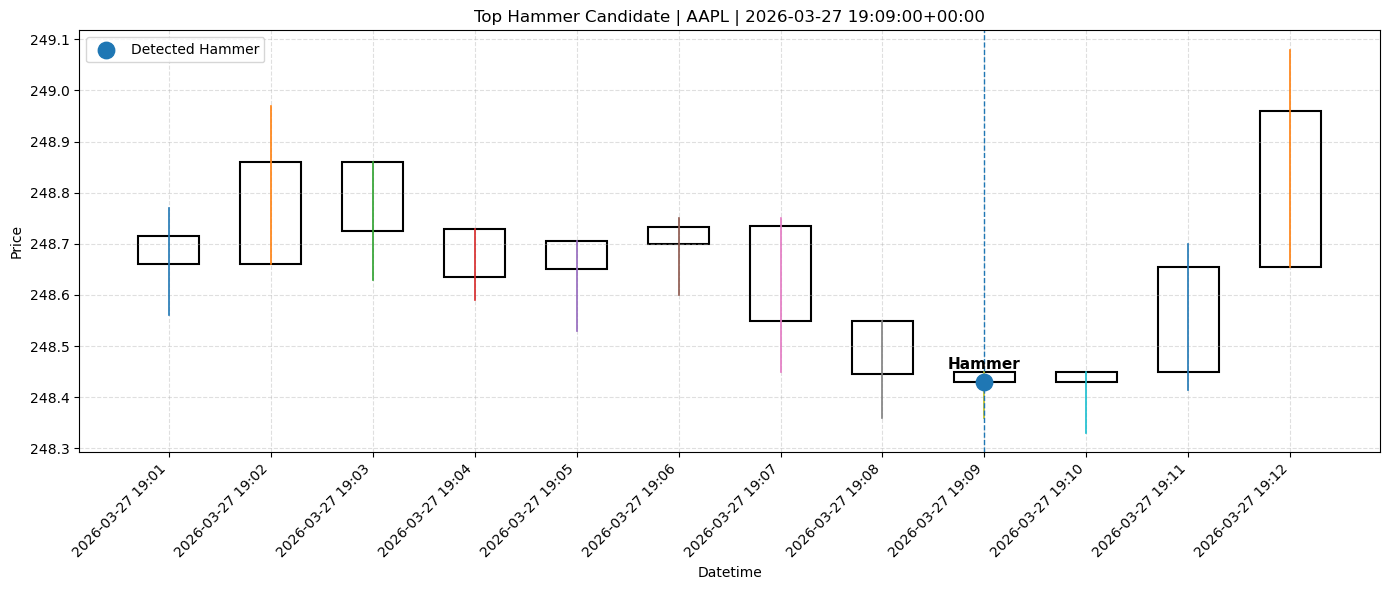

In [23]:
plot_candlestick_window(
    df_plot=plot_df,
    highlight_idx=local_event_idx,
    title=f"Top Hammer Candidate | {top_ticker} | {top_time}",
    pattern_label="Hammer"
)

Shooting Star

In [24]:
from stock_analysis.candlestick_patterns.Shooting_Star_Candlestick import ShootingStarCandlestickPattern
from stock_analysis.tools.candlestick_utils import (
    add_candlestick_features,
    safe_ratio,
    body_top_ratio,
)

In [25]:
def explain_shooting_star_candle(df_window: pd.DataFrame) -> dict:
    df_feat = add_candlestick_features(df_window)
    c = df_feat.iloc[-1]

    body = c["body"]
    range_ = c["range"]
    upper_wick = c["upper_wick"]
    lower_wick = c["lower_wick"]

    body_ratio = safe_ratio(body, range_)
    upper_body_ratio = safe_ratio(upper_wick, max(body, 1e-9))
    lower_body_ratio = safe_ratio(lower_wick, max(body, 1e-9))
    upper_range_ratio = safe_ratio(upper_wick, range_)
    lower_range_ratio = safe_ratio(lower_wick, range_)
    body_top_pos = body_top_ratio(c)

    shape_ok = (
        body_ratio <= 0.35
        and upper_body_ratio >= 2.2
        and lower_body_ratio <= 0.5
        and body_top_pos <= 0.4
    )

    return {
        "Datetime": c["Datetime"] if "Datetime" in c.index else None,
        "Open": c["Open"],
        "High": c["High"],
        "Low": c["Low"],
        "Close": c["Close"],
        "body": body,
        "range": range_,
        "upper_wick": upper_wick,
        "lower_wick": lower_wick,
        "body_ratio": body_ratio,
        "upper_body_ratio": upper_body_ratio,
        "lower_body_ratio": lower_body_ratio,
        "upper_range_ratio": upper_range_ratio,
        "lower_range_ratio": lower_range_ratio,
        "body_top_pos": body_top_pos,
        "direction": c["direction"],
        "shape_ok": shape_ok,
    }

In [26]:
pattern = ShootingStarCandlestickPattern()
window_size = 1

shooting_star_results = scan_all_candlestick_patterns(
    df_all=df_long,
    pattern=pattern,
    window_size=window_size,
)

print("Total detected Shooting Star patterns:", len(shooting_star_results))

if shooting_star_results.empty:
    print("No Shooting Star patterns detected.")
else:
    print("\nCounts by ticker:")
    print(shooting_star_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        shooting_star_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 1
Scanning tickers: ['AAPL', 'AMZN', 'MSFT', 'NVDA', 'TSLA']


ShootingStarCandlestickPattern returned invalid data: 1 validation error for PatternResult
confidence
  Input should be less than or equal to 100 [type=less_than_equal, input_value=110, input_type=int]
    For further information visit https://errors.pydantic.dev/2.12/v/less_than_equal
ShootingStarCandlestickPattern returned invalid data: 1 validation error for PatternResult
confidence
  Input should be less than or equal to 100 [type=less_than_equal, input_value=110, input_type=int]
    For further information visit https://errors.pydantic.dev/2.12/v/less_than_equal
ShootingStarCandlestickPattern returned invalid data: 1 validation error for PatternResult
confidence
  Input should be less than or equal to 100 [type=less_than_equal, input_value=110, input_type=int]
    For further information visit https://errors.pydantic.dev/2.12/v/less_than_equal
ShootingStarCandlestickPattern returned invalid data: 1 validation error for PatternResult
confidence
  Input should be less than or equal 

Total detected Shooting Star patterns: 167

Counts by ticker:
Ticker
AAPL    45
AMZN    37
TSLA    33
NVDA    32
MSFT    20
Name: count, dtype: int64

Top 20 by confidence:


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
0,AAPL,2026-03-26 13:58:00+00:00,ShootingStarCandlestickPattern,candlestick,100.0,28,28
4,AAPL,2026-03-26 18:48:00+00:00,ShootingStarCandlestickPattern,candlestick,100.0,318,318
12,AAPL,2026-03-30 14:17:00+00:00,ShootingStarCandlestickPattern,candlestick,100.0,825,825
14,AAPL,2026-03-30 15:25:00+00:00,ShootingStarCandlestickPattern,candlestick,100.0,893,893
36,AAPL,2026-04-02 14:26:00+00:00,ShootingStarCandlestickPattern,candlestick,100.0,2004,2004
37,AAPL,2026-04-02 14:56:00+00:00,ShootingStarCandlestickPattern,candlestick,100.0,2034,2034
41,AAPL,2026-04-02 16:30:00+00:00,ShootingStarCandlestickPattern,candlestick,100.0,2128,2128
42,AAPL,2026-04-02 17:34:00+00:00,ShootingStarCandlestickPattern,candlestick,100.0,2192,2192
45,AMZN,2026-03-26 14:18:00+00:00,ShootingStarCandlestickPattern,candlestick,100.0,48,48
56,AMZN,2026-03-30 14:40:00+00:00,ShootingStarCandlestickPattern,candlestick,100.0,848,848


In [27]:
if shooting_star_results.empty:
    print("No Shooting Star patterns found, cannot select top candidate.")
else:
    top_shooting_star = (
        shooting_star_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Shooting Star candidate:")
    print(top_shooting_star)

    top_ticker = top_shooting_star["Ticker"]
    top_event_idx = int(top_shooting_star["WindowEndIdx"])
    top_time = top_shooting_star["Datetime"]

    print("\nSelected ticker:", top_ticker)
    print("Event index:", top_event_idx)
    print("Event time:", top_time)

Top Shooting Star candidate:
Ticker                                      AAPL
Datetime               2026-03-26 13:58:00+00:00
Pattern           ShootingStarCandlestickPattern
Category                             candlestick
Confidence                                 100.0
WindowStartIdx                                28
WindowEndIdx                                  28
Name: 0, dtype: object

Selected ticker: AAPL
Event index: 28
Event time: 2026-03-26 13:58:00+00:00


In [28]:
plot_df, local_event_idx = extract_pattern_context(
    df_all=df_long,
    ticker=top_ticker,
    event_idx=top_event_idx,
    left_context=8,
    right_context=3,
)

print("Plot window shape:", plot_df.shape)
display(plot_df.head())
display(plot_df.tail())

Plot window shape: (12, 6)


Price,Datetime,Ticker,Open,High,Low,Close
0,2026-03-26 13:50:00+00:00,AAPL,252.397202,252.470001,252.210007,252.350006
1,2026-03-26 13:51:00+00:00,AAPL,252.369995,252.574997,252.330002,252.570007
2,2026-03-26 13:52:00+00:00,AAPL,252.570007,252.570007,252.339996,252.440002
3,2026-03-26 13:53:00+00:00,AAPL,252.429993,252.899994,252.320007,252.824997
4,2026-03-26 13:54:00+00:00,AAPL,252.800095,252.949997,252.740005,252.845001


Price,Datetime,Ticker,Open,High,Low,Close
7,2026-03-26 13:57:00+00:00,AAPL,253.020004,253.059998,252.779999,252.979996
8,2026-03-26 13:58:00+00:00,AAPL,252.970001,253.179993,252.970001,253.020004
9,2026-03-26 13:59:00+00:00,AAPL,253.050003,253.850006,252.889999,253.770004
10,2026-03-26 14:00:00+00:00,AAPL,253.800003,253.850006,253.460007,253.610001
11,2026-03-26 14:01:00+00:00,AAPL,253.589996,254.089996,253.550003,254.059998


In [29]:
target_candle_df = plot_df.iloc[[local_event_idx]].copy().reset_index(drop=True)

shooting_star_explanation = explain_shooting_star_candle(target_candle_df)

print("Extracted Shooting Star explanation:")
for k, v in shooting_star_explanation.items():
    print(f"{k}: {v}")

Extracted Shooting Star explanation:
Datetime: 2026-03-26 13:58:00+00:00
Open: 252.97000122070312
High: 253.17999267578125
Low: 252.97000122070312
Close: 253.02000427246094
body: 0.0500030517578125
range: 0.209991455078125
upper_wick: 0.1599884033203125
lower_wick: 0.0
body_ratio: 0.23811945938090393
upper_body_ratio: 3.1995727799816907
lower_body_ratio: 0.0
upper_range_ratio: 0.761880540619096
lower_range_ratio: 0.0
body_top_pos: 0.23811945938090393
direction: bullish
shape_ok: True


In [30]:
shooting_star_explanation_df = pd.DataFrame([shooting_star_explanation])
display(shooting_star_explanation_df)

,Datetime,Open,High,Low,Close,body,range,upper_wick,lower_wick,body_ratio,upper_body_ratio,lower_body_ratio,upper_range_ratio,lower_range_ratio,body_top_pos,direction,shape_ok
0,2026-03-26 13:58:00+00:00,252.970001,253.179993,252.970001,253.020004,0.050003,0.209991,0.159988,0.0,0.238119,3.199573,0.0,0.761881,0.0,0.238119,bullish,True


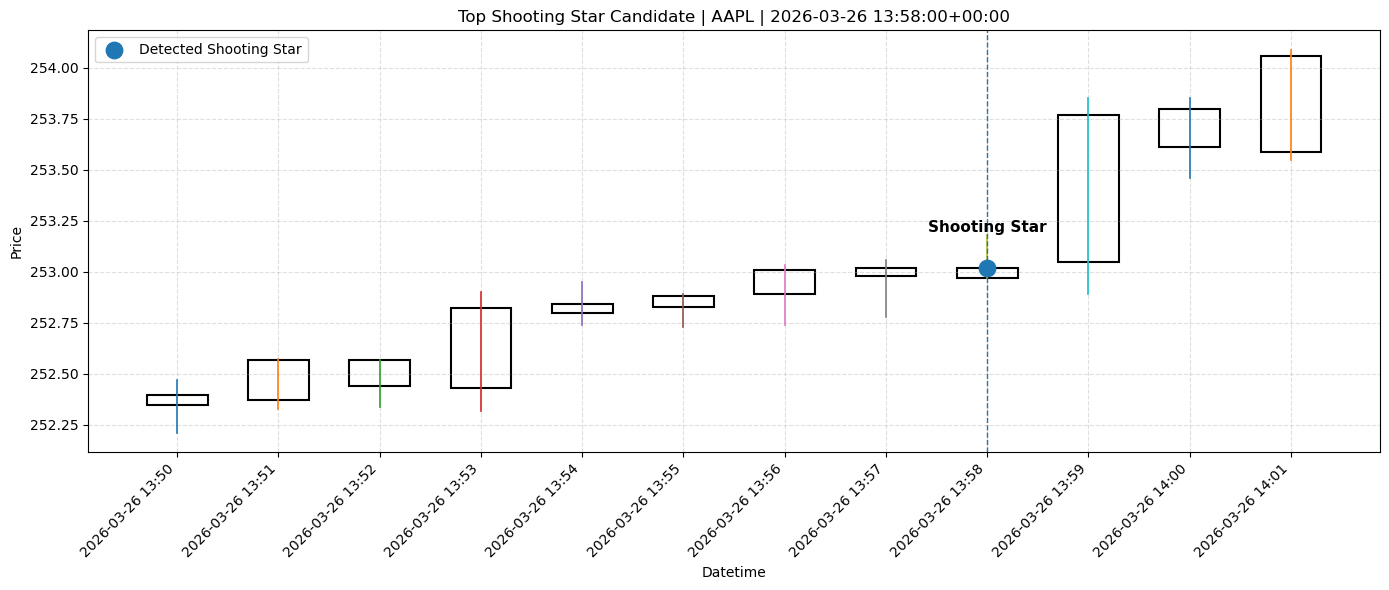

In [31]:
plot_candlestick_window(
    df_plot=plot_df,
    highlight_idx=local_event_idx,
    title=f"Top Shooting Star Candidate | {top_ticker} | {top_time}",
    pattern_label="Shooting Star"
)

Inverted Hammer

In [32]:
from stock_analysis.candlestick_patterns.Inverted_Hammer_Candlestick import InvertedHammerCandlestickPattern
from stock_analysis.tools.candlestick_utils import (
    add_candlestick_features,
    safe_ratio,
    body_top_ratio,
)

In [33]:
def explain_inverted_hammer_candle(df_window: pd.DataFrame) -> dict:
    df_feat = add_candlestick_features(df_window)
    c = df_feat.iloc[-1]

    body = c["body"]
    range_ = c["range"]
    upper_wick = c["upper_wick"]
    lower_wick = c["lower_wick"]

    body_ratio = safe_ratio(body, range_)
    upper_body_ratio = safe_ratio(upper_wick, max(body, 1e-9))
    lower_body_ratio = safe_ratio(lower_wick, max(body, 1e-9))
    upper_range_ratio = safe_ratio(upper_wick, range_)
    lower_range_ratio = safe_ratio(lower_wick, range_)
    body_top_pos = body_top_ratio(c)

    shape_ok = (
        body_ratio <= 0.35
        and upper_body_ratio >= 2.2
        and lower_body_ratio <= 0.4
        and body_top_pos <= 0.45
    )

    return {
        "Datetime": c["Datetime"] if "Datetime" in c.index else None,
        "Open": c["Open"],
        "High": c["High"],
        "Low": c["Low"],
        "Close": c["Close"],
        "body": body,
        "range": range_,
        "upper_wick": upper_wick,
        "lower_wick": lower_wick,
        "body_ratio": body_ratio,
        "upper_body_ratio": upper_body_ratio,
        "lower_body_ratio": lower_body_ratio,
        "upper_range_ratio": upper_range_ratio,
        "lower_range_ratio": lower_range_ratio,
        "body_top_pos": body_top_pos,
        "direction": c["direction"],
        "shape_ok": shape_ok,
    }

In [34]:
pattern = InvertedHammerCandlestickPattern()
window_size = 1

inverted_hammer_results = scan_all_candlestick_patterns(
    df_all=df_long,
    pattern=pattern,
    window_size=window_size,
)

print("Total detected Inverted Hammer patterns:", len(inverted_hammer_results))

if inverted_hammer_results.empty:
    print("No Inverted Hammer patterns detected.")
else:
    print("\nCounts by ticker:")
    print(inverted_hammer_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        inverted_hammer_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 1
Scanning tickers: ['AAPL', 'AMZN', 'MSFT', 'NVDA', 'TSLA']
Total detected Inverted Hammer patterns: 220

Counts by ticker:
Ticker
AAPL    58
AMZN    52
TSLA    41
NVDA    38
MSFT    31
Name: count, dtype: int64

Top 20 by confidence:


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
2,AAPL,2026-03-26 14:40:00+00:00,InvertedHammerCandlestickPattern,candlestick,100.0,70,70
7,AAPL,2026-03-27 13:44:00+00:00,InvertedHammerCandlestickPattern,candlestick,100.0,404,404
9,AAPL,2026-03-27 16:04:00+00:00,InvertedHammerCandlestickPattern,candlestick,100.0,542,542
14,AAPL,2026-03-27 18:37:00+00:00,InvertedHammerCandlestickPattern,candlestick,100.0,695,695
33,AAPL,2026-03-31 17:04:00+00:00,InvertedHammerCandlestickPattern,candlestick,100.0,1382,1382
37,AAPL,2026-03-31 18:31:00+00:00,InvertedHammerCandlestickPattern,candlestick,100.0,1469,1469
38,AAPL,2026-03-31 18:51:00+00:00,InvertedHammerCandlestickPattern,candlestick,100.0,1489,1489
39,AAPL,2026-04-01 15:29:00+00:00,InvertedHammerCandlestickPattern,candlestick,100.0,1677,1677
44,AAPL,2026-04-01 17:31:00+00:00,InvertedHammerCandlestickPattern,candlestick,100.0,1799,1799
49,AAPL,2026-04-02 14:31:00+00:00,InvertedHammerCandlestickPattern,candlestick,100.0,2009,2009


In [35]:
if inverted_hammer_results.empty:
    print("No Inverted Hammer patterns found, cannot select top candidate.")
else:
    top_inverted_hammer = (
        inverted_hammer_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Inverted Hammer candidate:")
    print(top_inverted_hammer)

    top_ticker = top_inverted_hammer["Ticker"]
    top_event_idx = int(top_inverted_hammer["WindowEndIdx"])
    top_time = top_inverted_hammer["Datetime"]

    print("\nSelected ticker:", top_ticker)
    print("Event index:", top_event_idx)
    print("Event time:", top_time)

Top Inverted Hammer candidate:
Ticker                                        AAPL
Datetime                 2026-03-26 14:40:00+00:00
Pattern           InvertedHammerCandlestickPattern
Category                               candlestick
Confidence                                   100.0
WindowStartIdx                                  70
WindowEndIdx                                    70
Name: 2, dtype: object

Selected ticker: AAPL
Event index: 70
Event time: 2026-03-26 14:40:00+00:00


In [36]:
plot_df, local_event_idx = extract_pattern_context(
    df_all=df_long,
    ticker=top_ticker,
    event_idx=top_event_idx,
    left_context=8,
    right_context=3,
)

print("Plot window shape:", plot_df.shape)
display(plot_df.head())
display(plot_df.tail())

Plot window shape: (12, 6)


Price,Datetime,Ticker,Open,High,Low,Close
0,2026-03-26 14:32:00+00:00,AAPL,255.960007,256.200012,255.920105,256.119995
1,2026-03-26 14:33:00+00:00,AAPL,256.089996,256.145508,255.809998,255.900101
2,2026-03-26 14:34:00+00:00,AAPL,255.909302,256.029999,255.830002,256.010895
3,2026-03-26 14:35:00+00:00,AAPL,256.040009,256.119995,255.940002,255.940002
4,2026-03-26 14:36:00+00:00,AAPL,255.940002,256.125000,255.899994,255.970901


Price,Datetime,Ticker,Open,High,Low,Close
7,2026-03-26 14:39:00+00:00,AAPL,256.065002,256.260010,256.065002,256.230011
8,2026-03-26 14:40:00+00:00,AAPL,256.230011,256.730011,256.220001,256.325012
9,2026-03-26 14:41:00+00:00,AAPL,256.309998,256.410004,255.850006,256.369995
10,2026-03-26 14:42:00+00:00,AAPL,256.369995,256.569397,256.220001,256.400085
11,2026-03-26 14:43:00+00:00,AAPL,256.404999,256.539886,256.320007,256.459991


In [37]:
target_candle_df = plot_df.iloc[[local_event_idx]].copy().reset_index(drop=True)

inverted_hammer_explanation = explain_inverted_hammer_candle(target_candle_df)

print("Extracted Inverted Hammer explanation:")
for k, v in inverted_hammer_explanation.items():
    print(f"{k}: {v}")

Extracted Inverted Hammer explanation:
Datetime: 2026-03-26 14:40:00+00:00
Open: 256.2300109863281
High: 256.7300109863281
Low: 256.2200012207031
Close: 256.32501220703125
body: 0.095001220703125
range: 0.510009765625
upper_wick: 0.404998779296875
lower_wick: 0.010009765625
body_ratio: 0.18627333652465294
upper_body_ratio: 4.263090266623836
lower_body_ratio: 0.10536460006424671
upper_range_ratio: 0.7941000478697942
lower_range_ratio: 0.019626615605552896
body_top_pos: 0.20589995213020584
direction: bullish
shape_ok: True


In [38]:
inverted_hammer_explanation_df = pd.DataFrame([inverted_hammer_explanation])
display(inverted_hammer_explanation_df)

,Datetime,Open,High,Low,Close,body,range,upper_wick,lower_wick,body_ratio,upper_body_ratio,lower_body_ratio,upper_range_ratio,lower_range_ratio,body_top_pos,direction,shape_ok
0,2026-03-26 14:40:00+00:00,256.230011,256.730011,256.220001,256.325012,0.095001,0.51001,0.404999,0.01001,0.186273,4.26309,0.105365,0.7941,0.019627,0.2059,bullish,True


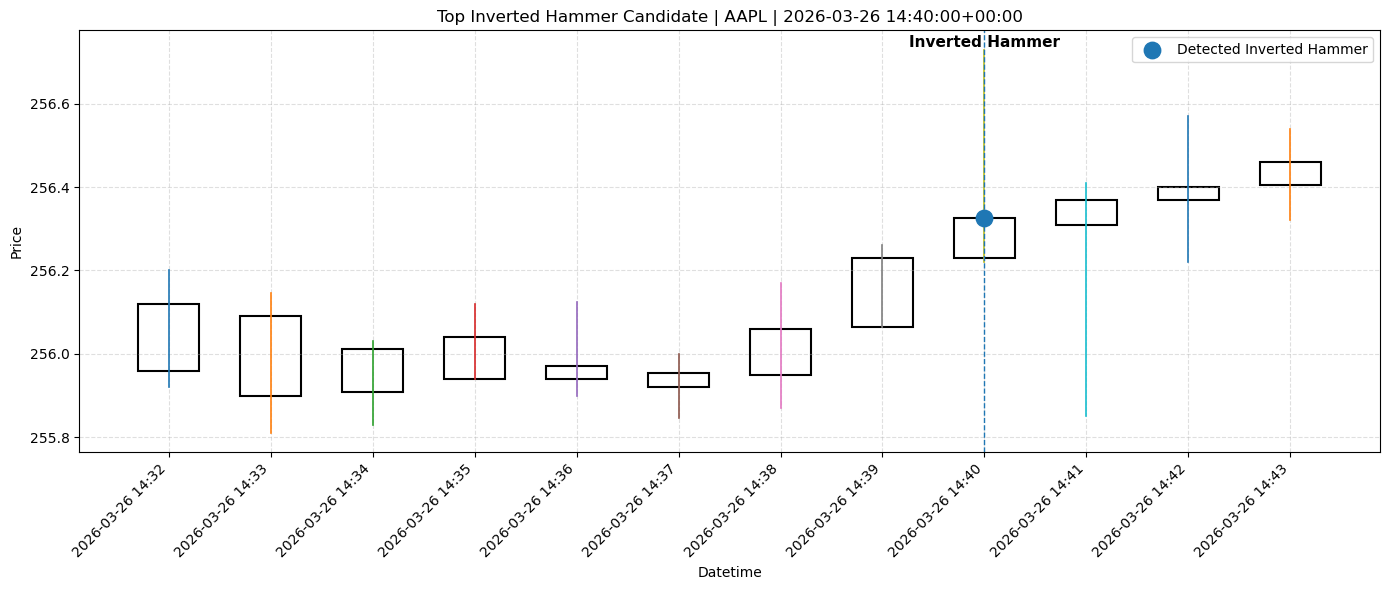

In [39]:
plot_candlestick_window(
    df_plot=plot_df,
    highlight_idx=local_event_idx,
    title=f"Top Inverted Hammer Candidate | {top_ticker} | {top_time}",
    pattern_label="Inverted Hammer"
)

Bullish Engulfing Pattern

In [40]:
from stock_analysis.candlestick_patterns.Bullish_Engulfing_Candlestick import BullishEngulfingCandlestickPattern
from stock_analysis.tools.candlestick_utils import (
    add_candlestick_features,
    safe_ratio,
)

In [41]:
def explain_bullish_engulfing(df_window: pd.DataFrame) -> dict:
    df_feat = add_candlestick_features(df_window)

    prev = df_feat.iloc[-2]
    curr = df_feat.iloc[-1]

    prev_body = prev["body"]
    curr_body = curr["body"]

    prev_range = prev["range"]
    curr_range = curr["range"]

    prev_body_ratio = safe_ratio(prev_body, prev_range)
    curr_body_ratio = safe_ratio(curr_body, curr_range)

    body_ratio = safe_ratio(curr_body, prev_body)
    range_ratio = safe_ratio(curr_range, prev_range)

    shape_ok = (
        prev["direction"] == "bearish"
        and curr["direction"] == "bullish"
        and curr["Open"] < prev["Close"]
        and curr["Close"] > prev["Open"]
    )

    quality_ok = not (
        prev_body_ratio < 0.25 or curr_body_ratio < 0.45 or body_ratio < 1.15
    )

    return {
        "Prev_Datetime": prev["Datetime"] if "Datetime" in prev.index else None,
        "Curr_Datetime": curr["Datetime"] if "Datetime" in curr.index else None,

        "Prev_Open": prev["Open"],
        "Prev_High": prev["High"],
        "Prev_Low": prev["Low"],
        "Prev_Close": prev["Close"],
        "Prev_Direction": prev["direction"],
        "Prev_Body": prev_body,
        "Prev_Range": prev_range,
        "Prev_Body_Ratio": prev_body_ratio,

        "Curr_Open": curr["Open"],
        "Curr_High": curr["High"],
        "Curr_Low": curr["Low"],
        "Curr_Close": curr["Close"],
        "Curr_Direction": curr["direction"],
        "Curr_Body": curr_body,
        "Curr_Range": curr_range,
        "Curr_Body_Ratio": curr_body_ratio,

        "Body_Ratio_Curr_to_Prev": body_ratio,
        "Range_Ratio_Curr_to_Prev": range_ratio,

        "Strict_Engulfing_Shape_OK": shape_ok,
        "Quality_OK": quality_ok,
    }

In [42]:
pattern = BullishEngulfingCandlestickPattern()
window_size = 2

bullish_engulfing_results = scan_all_candlestick_patterns(
    df_all=df_long,
    pattern=pattern,
    window_size=window_size,
)

print("Total detected Bullish Engulfing patterns:", len(bullish_engulfing_results))

if bullish_engulfing_results.empty:
    print("No Bullish Engulfing patterns detected.")
else:
    print("\nCounts by ticker:")
    print(bullish_engulfing_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        bullish_engulfing_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 2
Scanning tickers: ['AAPL', 'AMZN', 'MSFT', 'NVDA', 'TSLA']
Total detected Bullish Engulfing patterns: 254

Counts by ticker:
Ticker
NVDA    60
AAPL    57
AMZN    49
MSFT    48
TSLA    40
Name: count, dtype: int64

Top 20 by confidence:


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
1,AAPL,2026-03-26 13:53:00+00:00,BullishEngulfingCandlestickPattern,candlestick,100.0,22,23
4,AAPL,2026-03-26 15:46:00+00:00,BullishEngulfingCandlestickPattern,candlestick,100.0,135,136
6,AAPL,2026-03-26 17:55:00+00:00,BullishEngulfingCandlestickPattern,candlestick,100.0,264,265
10,AAPL,2026-03-27 14:24:00+00:00,BullishEngulfingCandlestickPattern,candlestick,100.0,443,444
11,AAPL,2026-03-27 14:52:00+00:00,BullishEngulfingCandlestickPattern,candlestick,100.0,471,472
16,AAPL,2026-03-27 17:06:00+00:00,BullishEngulfingCandlestickPattern,candlestick,100.0,603,604
21,AAPL,2026-03-30 14:38:00+00:00,BullishEngulfingCandlestickPattern,candlestick,100.0,845,846
23,AAPL,2026-03-30 16:30:00+00:00,BullishEngulfingCandlestickPattern,candlestick,100.0,957,958
24,AAPL,2026-03-30 18:10:00+00:00,BullishEngulfingCandlestickPattern,candlestick,100.0,1057,1058
26,AAPL,2026-03-30 19:18:00+00:00,BullishEngulfingCandlestickPattern,candlestick,100.0,1125,1126


In [43]:
if bullish_engulfing_results.empty:
    print("No Bullish Engulfing patterns found, cannot select top candidate.")
else:
    top_bullish_engulfing = (
        bullish_engulfing_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Bullish Engulfing candidate:")
    print(top_bullish_engulfing)

    top_ticker = top_bullish_engulfing["Ticker"]
    top_start_idx = int(top_bullish_engulfing["WindowStartIdx"])
    top_end_idx = int(top_bullish_engulfing["WindowEndIdx"])
    top_time = top_bullish_engulfing["Datetime"]

    print("\nSelected ticker:", top_ticker)
    print("Window:", top_start_idx, "to", top_end_idx)
    print("Event time:", top_time)

Top Bullish Engulfing candidate:
Ticker                                          AAPL
Datetime                   2026-03-26 13:53:00+00:00
Pattern           BullishEngulfingCandlestickPattern
Category                                 candlestick
Confidence                                     100.0
WindowStartIdx                                    22
WindowEndIdx                                      23
Name: 1, dtype: object

Selected ticker: AAPL
Window: 22 to 23
Event time: 2026-03-26 13:53:00+00:00


In [44]:
plot_df, local_event_idx = extract_pattern_context(
    df_all=df_long,
    ticker=top_ticker,
    event_idx=top_end_idx,
    left_context=8,
    right_context=3,
)

print("Plot window shape:", plot_df.shape)
display(plot_df.head())
display(plot_df.tail())

Plot window shape: (12, 6)


Price,Datetime,Ticker,Open,High,Low,Close
0,2026-03-26 13:45:00+00:00,AAPL,251.860001,252.080002,251.809998,251.979996
1,2026-03-26 13:46:00+00:00,AAPL,252.009995,252.110001,251.809998,252.039993
2,2026-03-26 13:47:00+00:00,AAPL,252.020004,252.419998,251.940002,252.399994
3,2026-03-26 13:48:00+00:00,AAPL,252.399994,252.399994,252.225006,252.384995
4,2026-03-26 13:49:00+00:00,AAPL,252.369995,252.449997,252.245697,252.330002


Price,Datetime,Ticker,Open,High,Low,Close
7,2026-03-26 13:52:00+00:00,AAPL,252.570007,252.570007,252.339996,252.440002
8,2026-03-26 13:53:00+00:00,AAPL,252.429993,252.899994,252.320007,252.824997
9,2026-03-26 13:54:00+00:00,AAPL,252.800095,252.949997,252.740005,252.845001
10,2026-03-26 13:55:00+00:00,AAPL,252.830002,252.893997,252.730606,252.880005
11,2026-03-26 13:56:00+00:00,AAPL,252.889999,253.035004,252.740005,253.009995


In [45]:
df_ticker_full = (
    df_long[df_long["Ticker"] == top_ticker]
    .sort_values("Datetime")
    .reset_index(drop=True)
    .copy()
)

engulfing_window_df = df_ticker_full.iloc[top_start_idx:top_end_idx + 1].reset_index(drop=True)

print("Bullish Engulfing 2-candle window:")
display(engulfing_window_df)

Bullish Engulfing 2-candle window:


Price,Datetime,Ticker,Open,High,Low,Close
0,2026-03-26 13:52:00+00:00,AAPL,252.570007,252.570007,252.339996,252.440002
1,2026-03-26 13:53:00+00:00,AAPL,252.429993,252.899994,252.320007,252.824997


In [46]:
bullish_engulfing_explanation = explain_bullish_engulfing(engulfing_window_df)

print("Extracted Bullish Engulfing explanation:")
for k, v in bullish_engulfing_explanation.items():
    print(f"{k}: {v}")

Extracted Bullish Engulfing explanation:
Prev_Datetime: 2026-03-26 13:52:00+00:00
Curr_Datetime: 2026-03-26 13:53:00+00:00
Prev_Open: 252.57000732421875
Prev_High: 252.57000732421875
Prev_Low: 252.33999633789062
Prev_Close: 252.44000244140625
Prev_Direction: bearish
Prev_Body: 0.1300048828125
Prev_Range: 0.230010986328125
Prev_Body_Ratio: 0.5652116226615365
Curr_Open: 252.42999267578125
Curr_High: 252.89999389648438
Curr_Low: 252.32000732421875
Curr_Close: 252.8249969482422
Curr_Direction: bullish
Curr_Body: 0.3950042724609375
Curr_Range: 0.579986572265625
Curr_Body_Ratio: 0.6810576164167325
Body_Ratio_Curr_to_Prev: 3.0383802816901406
Range_Ratio_Curr_to_Prev: 2.521560302507629
Strict_Engulfing_Shape_OK: True
Quality_OK: True


In [47]:
bullish_engulfing_explanation_df = pd.DataFrame([bullish_engulfing_explanation])
display(bullish_engulfing_explanation_df)

,Prev_Datetime,Curr_Datetime,Prev_Open,Prev_High,Prev_Low,Prev_Close,Prev_Direction,Prev_Body,Prev_Range,Prev_Body_Ratio,...,Curr_Low,Curr_Close,Curr_Direction,Curr_Body,Curr_Range,Curr_Body_Ratio,Body_Ratio_Curr_to_Prev,Range_Ratio_Curr_to_Prev,Strict_Engulfing_Shape_OK,Quality_OK
0,2026-03-26 13:52:00+00:00,2026-03-26 13:53:00+00:00,252.570007,252.570007,252.339996,252.440002,bearish,0.130005,0.230011,0.565212,...,252.320007,252.824997,bullish,0.395004,0.579987,0.681058,3.03838,2.52156,True,True


In [48]:
def plot_bullish_engulfing_window(
    df_plot: pd.DataFrame,
    prev_idx: int,
    curr_idx: int,
    title: str = "Bullish Engulfing Pattern",
):
    """
    Plot a candlestick window for bullish engulfing.
    
    Parameters
    ----------
    df_plot : pd.DataFrame
        Context window containing OHLC columns and Datetime.
    prev_idx : int
        Local index of the previous candle (bearish candle).
    curr_idx : int
        Local index of the current candle (bullish engulfing candle).
    title : str
        Plot title.
    """
    df_plot = df_plot.copy().reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(15, 6))
    x = np.arange(len(df_plot))
    candle_width = 0.6

    # -------------------------
    # 1. Draw candlesticks
    # -------------------------
    for i, row in df_plot.iterrows():
        open_ = row["Open"]
        high_ = row["High"]
        low_ = row["Low"]
        close_ = row["Close"]

        # Wick
        ax.plot([i, i], [low_, high_], linewidth=1.2)

        # Body
        body_low = min(open_, close_)
        body_height = abs(close_ - open_)

        # avoid invisible body
        display_body_height = max(body_height, 0.001)

        rect = Rectangle(
            (i - candle_width / 2, body_low),
            candle_width,
            display_body_height,
            fill=False,
            linewidth=1.5
        )
        ax.add_patch(rect)

    # -------------------------
    # 2. Highlight previous candle
    # -------------------------
    prev_row = df_plot.iloc[prev_idx]
    prev_body_low = min(prev_row["Open"], prev_row["Close"])
    prev_body_high = max(prev_row["Open"], prev_row["Close"])

    prev_highlight = Rectangle(
        (prev_idx - candle_width / 2 - 0.08, prev_body_low),
        candle_width + 0.16,
        max(prev_body_high - prev_body_low, 0.001),
        fill=False,
        linewidth=2.5,
        linestyle="--"
    )
    ax.add_patch(prev_highlight)

    ax.text(
        prev_idx,
        prev_row["High"],
        "Prev",
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="bottom"
    )

    # -------------------------
    # 3. Highlight current candle
    # -------------------------
    curr_row = df_plot.iloc[curr_idx]
    curr_body_low = min(curr_row["Open"], curr_row["Close"])
    curr_body_high = max(curr_row["Open"], curr_row["Close"])

    curr_highlight = Rectangle(
        (curr_idx - candle_width / 2 - 0.08, curr_body_low),
        candle_width + 0.16,
        max(curr_body_high - curr_body_low, 0.001),
        fill=False,
        linewidth=2.5
    )
    ax.add_patch(curr_highlight)

    ax.text(
        curr_idx,
        curr_row["High"],
        "Curr",
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="bottom"
    )

    # -------------------------
    # 4. Draw previous body range lines
    # -------------------------
    ax.hlines(
        y=prev_row["Open"],
        xmin=prev_idx - 0.35,
        xmax=curr_idx + 0.35,
        linestyles="--",
        linewidth=1.2
    )
    ax.hlines(
        y=prev_row["Close"],
        xmin=prev_idx - 0.35,
        xmax=curr_idx + 0.35,
        linestyles="--",
        linewidth=1.2
    )

    ax.text(
        curr_idx + 0.45,
        prev_row["Open"],
        f"Prev Open = {prev_row['Open']:.3f}",
        fontsize=9,
        va="center"
    )
    ax.text(
        curr_idx + 0.45,
        prev_row["Close"],
        f"Prev Close = {prev_row['Close']:.3f}",
        fontsize=9,
        va="center"
    )

    # -------------------------
    # 5. Mark engulfing region with outer frame
    # -------------------------
    left_edge = prev_idx - candle_width / 2 - 0.2
    right_edge = curr_idx + candle_width / 2 + 0.2
    bottom_edge = min(
        prev_row["Low"], curr_row["Low"],
        prev_body_low, curr_body_low
    )
    top_edge = max(
        prev_row["High"], curr_row["High"],
        prev_body_high, curr_body_high
    )

    outer_box = Rectangle(
        (left_edge, bottom_edge),
        right_edge - left_edge,
        top_edge - bottom_edge,
        fill=False,
        linewidth=1.8,
        linestyle=":"
    )
    ax.add_patch(outer_box)

    # -------------------------
    # 6. Annotation for engulfing condition
    # -------------------------
    engulf_text = (
        f"Curr Open ({curr_row['Open']:.3f}) < Prev Close ({prev_row['Close']:.3f})\n"
        f"Curr Close ({curr_row['Close']:.3f}) > Prev Open ({prev_row['Open']:.3f})"
    )

    ax.text(
        curr_idx + 0.6,
        top_edge,
        engulf_text,
        fontsize=9,
        va="top"
    )

    # -------------------------
    # 7. Axes / labels
    # -------------------------
    ax.set_xticks(x)
    ax.set_xticklabels(
        [str(pd.to_datetime(dt))[:16] for dt in df_plot["Datetime"]],
        rotation=45,
        ha="right"
    )

    ax.set_title(title)
    ax.set_xlabel("Datetime")
    ax.set_ylabel("Price")
    ax.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

In [49]:
def get_local_indices_for_multi_candle_pattern(
    plot_df: pd.DataFrame,
    full_df_ticker: pd.DataFrame,
    start_idx: int,
    end_idx: int,
):
    """
    Convert full ticker indices into local indices inside plot_df.
    Assumes plot_df is a slice taken from full_df_ticker in the same order.
    """
    plot_times = list(plot_df["Datetime"])
    full_times = list(full_df_ticker.iloc[start_idx:end_idx + 1]["Datetime"])

    local_indices = []
    for t in full_times:
        local_indices.append(plot_times.index(t))

    return local_indices

In [50]:
plot_df, _ = extract_pattern_context(
    df_all=df_long,
    ticker=top_ticker,
    event_idx=top_end_idx,
    left_context=8,
    right_context=3,
)

In [51]:
local_prev_idx, local_curr_idx = get_local_indices_for_multi_candle_pattern(
    plot_df=plot_df,
    full_df_ticker=df_ticker_full,
    start_idx=top_start_idx,
    end_idx=top_end_idx,
)

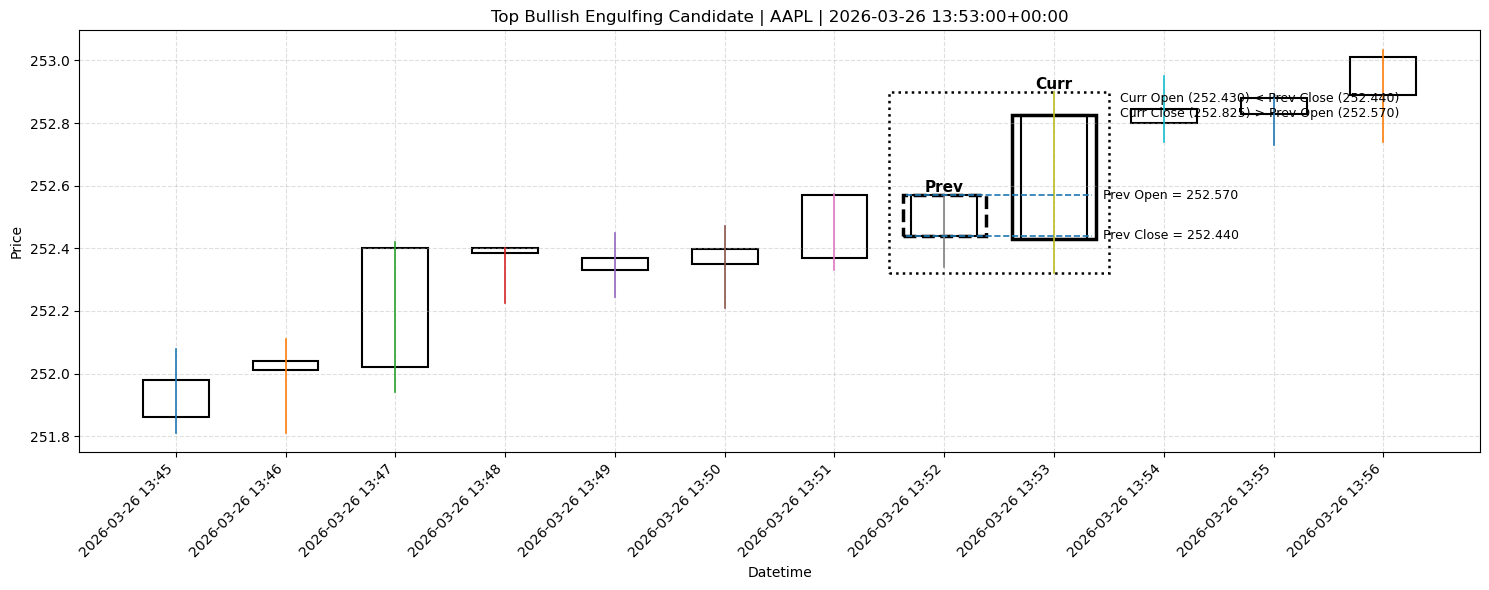

In [52]:
plot_bullish_engulfing_window(
    df_plot=plot_df,
    prev_idx=local_prev_idx,
    curr_idx=local_curr_idx,
    title=f"Top Bullish Engulfing Candidate | {top_ticker} | {top_time}",
)

Bearish Engulfing Pattern

In [53]:
from stock_analysis.candlestick_patterns.Bearish_Engulfing_Candlestick import BearishEngulfingCandlestickPattern
from stock_analysis.tools.candlestick_utils import (
    add_candlestick_features,
    safe_ratio,
)

In [54]:
def explain_bearish_engulfing(df_window: pd.DataFrame) -> dict:
    df_feat = add_candlestick_features(df_window)

    prev = df_feat.iloc[-2]
    curr = df_feat.iloc[-1]

    prev_body = prev["body"]
    curr_body = curr["body"]

    prev_range = prev["range"]
    curr_range = curr["range"]

    prev_body_ratio = safe_ratio(prev_body, prev_range)
    curr_body_ratio = safe_ratio(curr_body, curr_range)

    body_ratio = safe_ratio(curr_body, prev_body)
    range_ratio = safe_ratio(curr_range, prev_range)

    shape_ok = (
        prev["direction"] == "bullish"
        and curr["direction"] == "bearish"
        and curr["Open"] > prev["Close"]
        and curr["Close"] < prev["Open"]
    )

    quality_ok = not (
        prev_body_ratio < 0.25 or curr_body_ratio < 0.45 or body_ratio < 1.15
    )

    return {
        "Prev_Datetime": prev["Datetime"] if "Datetime" in prev.index else None,
        "Curr_Datetime": curr["Datetime"] if "Datetime" in curr.index else None,

        "Prev_Open": prev["Open"],
        "Prev_High": prev["High"],
        "Prev_Low": prev["Low"],
        "Prev_Close": prev["Close"],
        "Prev_Direction": prev["direction"],
        "Prev_Body": prev_body,
        "Prev_Range": prev_range,
        "Prev_Body_Ratio": prev_body_ratio,

        "Curr_Open": curr["Open"],
        "Curr_High": curr["High"],
        "Curr_Low": curr["Low"],
        "Curr_Close": curr["Close"],
        "Curr_Direction": curr["direction"],
        "Curr_Body": curr_body,
        "Curr_Range": curr_range,
        "Curr_Body_Ratio": curr_body_ratio,

        "Body_Ratio_Curr_to_Prev": body_ratio,
        "Range_Ratio_Curr_to_Prev": range_ratio,

        "Strict_Engulfing_Shape_OK": shape_ok,
        "Quality_OK": quality_ok,
    }

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def plot_bearish_engulfing_window(
    df_plot: pd.DataFrame,
    prev_idx: int,
    curr_idx: int,
    title: str = "Bearish Engulfing Pattern",
):
    """
    Plot a candlestick window for bearish engulfing.
    Only shows structural relationship, without numeric annotations.
    """
    df_plot = df_plot.copy().reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(15, 6))
    x = np.arange(len(df_plot))
    candle_width = 0.6

    # 1. Draw candlesticks
    for i, row in df_plot.iterrows():
        open_ = row["Open"]
        high_ = row["High"]
        low_ = row["Low"]
        close_ = row["Close"]

        # wick
        ax.plot([i, i], [low_, high_], linewidth=1.2)

        # body
        body_low = min(open_, close_)
        body_height = abs(close_ - open_)

        rect = Rectangle(
            (i - candle_width / 2, body_low),
            candle_width,
            max(body_height, 0.001),
            fill=False,
            linewidth=1.5
        )
        ax.add_patch(rect)

    # 2. Highlight previous candle
    prev_row = df_plot.iloc[prev_idx]
    prev_body_low = min(prev_row["Open"], prev_row["Close"])
    prev_body_high = max(prev_row["Open"], prev_row["Close"])

    prev_highlight = Rectangle(
        (prev_idx - candle_width / 2 - 0.08, prev_body_low),
        candle_width + 0.16,
        max(prev_body_high - prev_body_low, 0.001),
        fill=False,
        linewidth=2.5,
        linestyle="--"
    )
    ax.add_patch(prev_highlight)

    ax.text(
        prev_idx,
        prev_row["High"],
        "Prev",
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="bottom"
    )

    # 3. Highlight current candle
    curr_row = df_plot.iloc[curr_idx]
    curr_body_low = min(curr_row["Open"], curr_row["Close"])
    curr_body_high = max(curr_row["Open"], curr_row["Close"])

    curr_highlight = Rectangle(
        (curr_idx - candle_width / 2 - 0.08, curr_body_low),
        candle_width + 0.16,
        max(curr_body_high - curr_body_low, 0.001),
        fill=False,
        linewidth=2.5
    )
    ax.add_patch(curr_highlight)

    ax.text(
        curr_idx,
        curr_row["High"],
        "Curr",
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="bottom"
    )

    # 4. Outer frame around the pair
    left_edge = prev_idx - candle_width / 2 - 0.2
    right_edge = curr_idx + candle_width / 2 + 0.2
    bottom_edge = min(prev_row["Low"], curr_row["Low"], prev_body_low, curr_body_low)
    top_edge = max(prev_row["High"], curr_row["High"], prev_body_high, curr_body_high)

    outer_box = Rectangle(
        (left_edge, bottom_edge),
        right_edge - left_edge,
        top_edge - bottom_edge,
        fill=False,
        linewidth=1.8,
        linestyle=":"
    )
    ax.add_patch(outer_box)

    # 5. Arrow showing engulfing direction
    ax.annotate(
        "",
        xy=(curr_idx, (curr_body_low + curr_body_high) / 2),
        xytext=(prev_idx, (prev_body_low + prev_body_high) / 2),
        arrowprops=dict(arrowstyle="->", lw=1.5)
    )

    # 6. Axes / labels
    ax.set_xticks(x)
    ax.set_xticklabels(
        [str(pd.to_datetime(dt))[:16] for dt in df_plot["Datetime"]],
        rotation=45,
        ha="right"
    )

    ax.set_title(title)
    ax.set_xlabel("Datetime")
    ax.set_ylabel("Price")
    ax.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

In [56]:
pattern = BearishEngulfingCandlestickPattern()
window_size = 2

bearish_engulfing_results = scan_all_candlestick_patterns(
    df_all=df_long,
    pattern=pattern,
    window_size=window_size,
)

print("Total detected Bearish Engulfing patterns:", len(bearish_engulfing_results))

if bearish_engulfing_results.empty:
    print("No Bearish Engulfing patterns detected.")
else:
    print("\nCounts by ticker:")
    print(bearish_engulfing_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        bearish_engulfing_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 2
Scanning tickers: ['AAPL', 'AMZN', 'MSFT', 'NVDA', 'TSLA']
Total detected Bearish Engulfing patterns: 244

Counts by ticker:
Ticker
AMZN    51
MSFT    51
TSLA    49
AAPL    48
NVDA    45
Name: count, dtype: int64

Top 20 by confidence:


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
0,AAPL,2026-03-26 14:27:00+00:00,BearishEngulfingCandlestickPattern,candlestick,100.0,56,57
4,AAPL,2026-03-26 17:20:00+00:00,BearishEngulfingCandlestickPattern,candlestick,100.0,229,230
12,AAPL,2026-03-27 16:07:00+00:00,BearishEngulfingCandlestickPattern,candlestick,100.0,544,545
15,AAPL,2026-03-27 18:58:00+00:00,BearishEngulfingCandlestickPattern,candlestick,100.0,715,716
20,AAPL,2026-03-30 17:15:00+00:00,BearishEngulfingCandlestickPattern,candlestick,100.0,1002,1003
21,AAPL,2026-03-31 14:16:00+00:00,BearishEngulfingCandlestickPattern,candlestick,100.0,1213,1214
24,AAPL,2026-04-01 13:42:00+00:00,BearishEngulfingCandlestickPattern,candlestick,100.0,1569,1570
25,AAPL,2026-04-01 14:03:00+00:00,BearishEngulfingCandlestickPattern,candlestick,100.0,1590,1591
26,AAPL,2026-04-01 14:26:00+00:00,BearishEngulfingCandlestickPattern,candlestick,100.0,1613,1614
27,AAPL,2026-04-01 14:30:00+00:00,BearishEngulfingCandlestickPattern,candlestick,100.0,1617,1618


In [57]:
if bearish_engulfing_results.empty:
    print("No Bearish Engulfing patterns found, cannot select top candidate.")
else:
    top_bearish_engulfing = (
        bearish_engulfing_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Bearish Engulfing candidate:")
    print(top_bearish_engulfing)

    top_ticker = top_bearish_engulfing["Ticker"]
    top_start_idx = int(top_bearish_engulfing["WindowStartIdx"])
    top_end_idx = int(top_bearish_engulfing["WindowEndIdx"])
    top_time = top_bearish_engulfing["Datetime"]

    print("\nSelected ticker:", top_ticker)
    print("Window:", top_start_idx, "to", top_end_idx)
    print("Event time:", top_time)

Top Bearish Engulfing candidate:
Ticker                                          AAPL
Datetime                   2026-03-26 14:27:00+00:00
Pattern           BearishEngulfingCandlestickPattern
Category                                 candlestick
Confidence                                     100.0
WindowStartIdx                                    56
WindowEndIdx                                      57
Name: 0, dtype: object

Selected ticker: AAPL
Window: 56 to 57
Event time: 2026-03-26 14:27:00+00:00


In [58]:
plot_df, _ = extract_pattern_context(
    df_all=df_long,
    ticker=top_ticker,
    event_idx=top_end_idx,
    left_context=8,
    right_context=3,
)

print("Plot window shape:", plot_df.shape)
display(plot_df.head())
display(plot_df.tail())

Plot window shape: (12, 6)


Price,Datetime,Ticker,Open,High,Low,Close
0,2026-03-26 14:19:00+00:00,AAPL,255.389999,255.410004,255.064896,255.100006
1,2026-03-26 14:20:00+00:00,AAPL,255.089996,255.470001,254.940002,255.369995
2,2026-03-26 14:21:00+00:00,AAPL,255.360001,255.649994,255.335999,255.609894
3,2026-03-26 14:22:00+00:00,AAPL,255.600006,256.209991,255.581100,256.169891
4,2026-03-26 14:23:00+00:00,AAPL,256.130005,256.190002,255.929993,256.070007


Price,Datetime,Ticker,Open,High,Low,Close
7,2026-03-26 14:26:00+00:00,AAPL,256.079987,256.200012,256.079987,256.174896
8,2026-03-26 14:27:00+00:00,AAPL,256.184998,256.239990,255.831207,255.880005
9,2026-03-26 14:28:00+00:00,AAPL,255.899994,255.990005,255.720001,255.979996
10,2026-03-26 14:29:00+00:00,AAPL,255.955002,256.040009,255.810104,255.910004
11,2026-03-26 14:30:00+00:00,AAPL,255.899994,256.070007,255.830002,255.889999


In [59]:
df_ticker_full = (
    df_long[df_long["Ticker"] == top_ticker]
    .sort_values("Datetime")
    .reset_index(drop=True)
    .copy()
)

engulfing_window_df = df_ticker_full.iloc[top_start_idx:top_end_idx + 1].reset_index(drop=True)

print("Bearish Engulfing 2-candle window:")
display(engulfing_window_df)

Bearish Engulfing 2-candle window:


Price,Datetime,Ticker,Open,High,Low,Close
0,2026-03-26 14:26:00+00:00,AAPL,256.079987,256.200012,256.079987,256.174896
1,2026-03-26 14:27:00+00:00,AAPL,256.184998,256.239990,255.831207,255.880005


In [60]:
bearish_engulfing_explanation = explain_bearish_engulfing(engulfing_window_df)

print("Extracted Bearish Engulfing explanation:")
for k, v in bearish_engulfing_explanation.items():
    print(f"{k}: {v}")

Extracted Bearish Engulfing explanation:
Prev_Datetime: 2026-03-26 14:26:00+00:00
Curr_Datetime: 2026-03-26 14:27:00+00:00
Prev_Open: 256.0799865722656
Prev_High: 256.20001220703125
Prev_Low: 256.0799865722656
Prev_Close: 256.1748962402344
Prev_Direction: bullish
Prev_Body: 0.09490966796875
Prev_Range: 0.120025634765625
Prev_Body_Ratio: 0.790744978387999
Curr_Open: 256.18499755859375
Curr_High: 256.239990234375
Curr_Low: 255.83120727539062
Curr_Close: 255.8800048828125
Curr_Direction: bearish
Curr_Body: 0.30499267578125
Curr_Range: 0.408782958984375
Curr_Body_Ratio: 0.7460992907801418
Body_Ratio_Curr_to_Prev: 3.2135048231511254
Range_Ratio_Curr_to_Prev: 3.4057971014492754
Strict_Engulfing_Shape_OK: True
Quality_OK: True


In [61]:
bearish_engulfing_explanation_df = pd.DataFrame([bearish_engulfing_explanation])
display(bearish_engulfing_explanation_df)

,Prev_Datetime,Curr_Datetime,Prev_Open,Prev_High,Prev_Low,Prev_Close,Prev_Direction,Prev_Body,Prev_Range,Prev_Body_Ratio,...,Curr_Low,Curr_Close,Curr_Direction,Curr_Body,Curr_Range,Curr_Body_Ratio,Body_Ratio_Curr_to_Prev,Range_Ratio_Curr_to_Prev,Strict_Engulfing_Shape_OK,Quality_OK
0,2026-03-26 14:26:00+00:00,2026-03-26 14:27:00+00:00,256.079987,256.200012,256.079987,256.174896,bullish,0.09491,0.120026,0.790745,...,255.831207,255.880005,bearish,0.304993,0.408783,0.746099,3.213505,3.405797,True,True


In [62]:
local_prev_idx, local_curr_idx = get_local_indices_for_multi_candle_pattern(
    plot_df=plot_df,
    full_df_ticker=df_ticker_full,
    start_idx=top_start_idx,
    end_idx=top_end_idx,
)

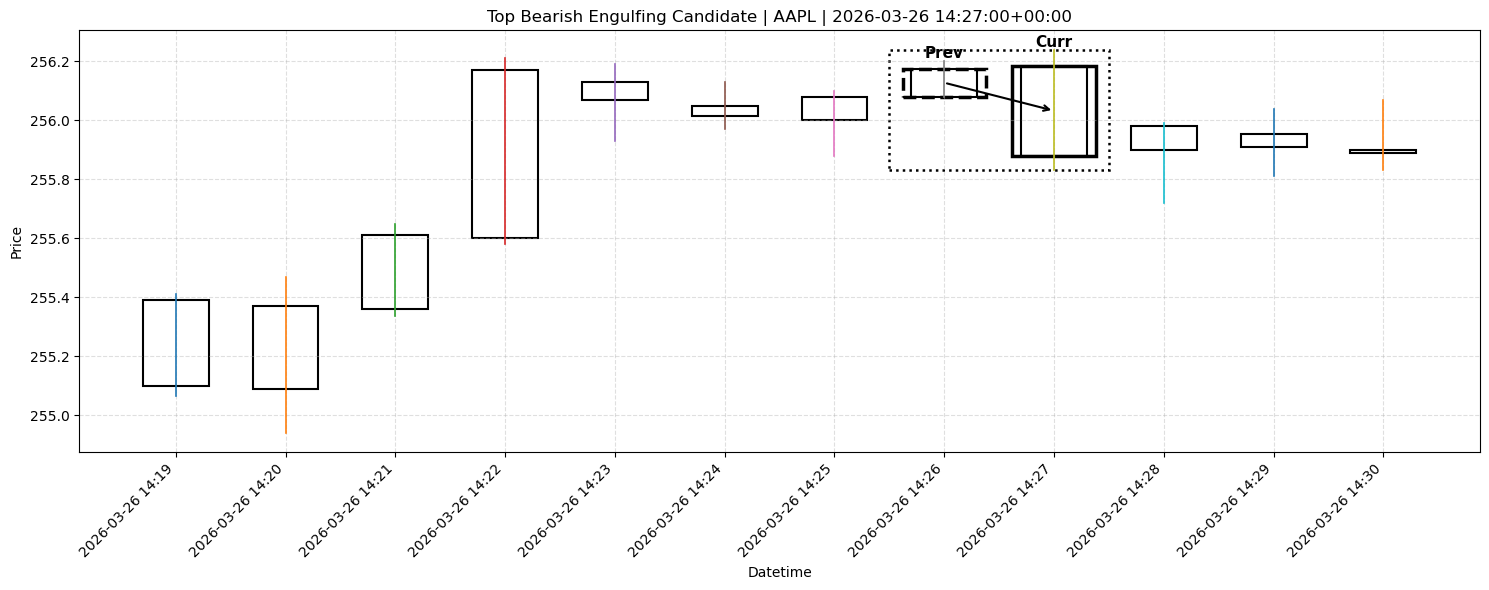

In [63]:
plot_bearish_engulfing_window(
    df_plot=plot_df,
    prev_idx=local_prev_idx,
    curr_idx=local_curr_idx,
    title=f"Top Bearish Engulfing Candidate | {top_ticker} | {top_time}",
)

Bullish Harami Pattern

In [64]:
from stock_analysis.candlestick_patterns.Bullish_Harami_Candlestick import BullishHaramiCandlestickPattern
from stock_analysis.tools.candlestick_utils import (
    add_candlestick_features,
    safe_ratio,
)

In [65]:
def explain_bullish_harami(df_window: pd.DataFrame) -> dict:
    df_feat = add_candlestick_features(df_window)

    prev = df_feat.iloc[-2]
    curr = df_feat.iloc[-1]

    prev_body_high = max(prev["Open"], prev["Close"])
    prev_body_low = min(prev["Open"], prev["Close"])
    curr_body_high = max(curr["Open"], curr["Close"])
    curr_body_low = min(curr["Open"], curr["Close"])

    prev_body_ratio = safe_ratio(prev["body"], prev["range"])
    curr_body_ratio = safe_ratio(curr["body"], curr["range"])
    size_ratio = safe_ratio(curr["body"], max(prev["body"], 1e-9))

    body_midpoint = (prev_body_high + prev_body_low) / 2
    centeredness = safe_ratio(
        min(curr_body_high - body_midpoint, body_midpoint - curr_body_low),
        max(prev["body"] / 2, 1e-9),
    )

    shape_ok = (
        prev["direction"] == "bearish"
        and curr["direction"] == "bullish"
        and prev_body_ratio >= 0.5
        and curr_body_ratio >= 0.15
        and curr_body_high < prev_body_high
        and curr_body_low > prev_body_low
        and size_ratio <= 0.65
    )

    return {
        "Prev_Datetime": prev["Datetime"] if "Datetime" in prev.index else None,
        "Curr_Datetime": curr["Datetime"] if "Datetime" in curr.index else None,

        "Prev_Open": prev["Open"],
        "Prev_High": prev["High"],
        "Prev_Low": prev["Low"],
        "Prev_Close": prev["Close"],
        "Prev_Direction": prev["direction"],
        "Prev_Body": prev["body"],
        "Prev_Range": prev["range"],
        "Prev_Body_Ratio": prev_body_ratio,

        "Curr_Open": curr["Open"],
        "Curr_High": curr["High"],
        "Curr_Low": curr["Low"],
        "Curr_Close": curr["Close"],
        "Curr_Direction": curr["direction"],
        "Curr_Body": curr["body"],
        "Curr_Range": curr["range"],
        "Curr_Body_Ratio": curr_body_ratio,

        "Prev_Body_High": prev_body_high,
        "Prev_Body_Low": prev_body_low,
        "Curr_Body_High": curr_body_high,
        "Curr_Body_Low": curr_body_low,

        "Size_Ratio_Curr_to_Prev": size_ratio,
        "Centeredness": centeredness,
        "Strict_Harami_Shape_OK": shape_ok,
    }

In [66]:
def plot_bullish_harami_window(
    df_plot: pd.DataFrame,
    prev_idx: int,
    curr_idx: int,
    title: str = "Bullish Harami Pattern",
):
    """
    Plot a bullish harami window.
    Shows structure only, without numeric annotations.
    """
    df_plot = df_plot.copy().reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(15, 6))
    x = np.arange(len(df_plot))
    candle_width = 0.6

    # 1. Draw all candlesticks
    for i, row in df_plot.iterrows():
        open_ = row["Open"]
        high_ = row["High"]
        low_ = row["Low"]
        close_ = row["Close"]

        ax.plot([i, i], [low_, high_], linewidth=1.2)

        body_low = min(open_, close_)
        body_height = abs(close_ - open_)

        rect = Rectangle(
            (i - candle_width / 2, body_low),
            candle_width,
            max(body_height, 0.001),
            fill=False,
            linewidth=1.5
        )
        ax.add_patch(rect)

    prev_row = df_plot.iloc[prev_idx]
    curr_row = df_plot.iloc[curr_idx]

    prev_body_low = min(prev_row["Open"], prev_row["Close"])
    prev_body_high = max(prev_row["Open"], prev_row["Close"])
    curr_body_low = min(curr_row["Open"], curr_row["Close"])
    curr_body_high = max(curr_row["Open"], curr_row["Close"])

    # 2. Highlight previous large candle
    prev_highlight = Rectangle(
        (prev_idx - candle_width / 2 - 0.08, prev_body_low),
        candle_width + 0.16,
        max(prev_body_high - prev_body_low, 0.001),
        fill=False,
        linewidth=2.5,
        linestyle="--"
    )
    ax.add_patch(prev_highlight)

    ax.text(
        prev_idx,
        prev_row["High"],
        "Prev",
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="bottom"
    )

    # 3. Highlight current small candle
    curr_highlight = Rectangle(
        (curr_idx - candle_width / 2 - 0.08, curr_body_low),
        candle_width + 0.16,
        max(curr_body_high - curr_body_low, 0.001),
        fill=False,
        linewidth=2.5
    )
    ax.add_patch(curr_highlight)

    ax.text(
        curr_idx,
        curr_row["High"],
        "Curr",
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="bottom"
    )

    # 4. Draw mother-body zone (body only)
    mother_box = Rectangle(
        (prev_idx - candle_width / 2 - 0.12, prev_body_low),
        candle_width + 0.24,
        max(prev_body_high - prev_body_low, 0.001),
        fill=False,
        linewidth=1.8,
        linestyle=":"
    )
    ax.add_patch(mother_box)

    # 5. Draw outer frame around the pair
    left_edge = prev_idx - candle_width / 2 - 0.2
    right_edge = curr_idx + candle_width / 2 + 0.2
    bottom_edge = min(prev_row["Low"], curr_row["Low"], prev_body_low, curr_body_low)
    top_edge = max(prev_row["High"], curr_row["High"], prev_body_high, curr_body_high)

    outer_box = Rectangle(
        (left_edge, bottom_edge),
        right_edge - left_edge,
        top_edge - bottom_edge,
        fill=False,
        linewidth=1.8,
        linestyle=":"
    )
    ax.add_patch(outer_box)

    # 6. Arrow showing containment relationship
    ax.annotate(
        "",
        xy=(curr_idx, (curr_body_low + curr_body_high) / 2),
        xytext=(prev_idx, (prev_body_low + prev_body_high) / 2),
        arrowprops=dict(arrowstyle="->", lw=1.5)
    )

    # 7. Axes / labels
    ax.set_xticks(x)
    ax.set_xticklabels(
        [str(pd.to_datetime(dt))[:16] for dt in df_plot["Datetime"]],
        rotation=45,
        ha="right"
    )

    ax.set_title(title)
    ax.set_xlabel("Datetime")
    ax.set_ylabel("Price")
    ax.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

In [67]:
pattern = BullishHaramiCandlestickPattern()
window_size = 2

bullish_harami_results = scan_all_candlestick_patterns(
    df_all=df_long,
    pattern=pattern,
    window_size=window_size,
)

print("Total detected Bullish Harami patterns:", len(bullish_harami_results))

if bullish_harami_results.empty:
    print("No Bullish Harami patterns detected.")
else:
    print("\nCounts by ticker:")
    print(bullish_harami_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        bullish_harami_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 2
Scanning tickers: ['AAPL', 'AMZN', 'MSFT', 'NVDA', 'TSLA']
Total detected Bullish Harami patterns: 253

Counts by ticker:
Ticker
MSFT    56
AAPL    54
TSLA    54
AMZN    50
NVDA    39
Name: count, dtype: int64

Top 20 by confidence:


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
6,AAPL,2026-03-26 16:36:00+00:00,BullishHaramiCandlestickPattern,candlestick,85.0,185,186
34,AAPL,2026-03-30 19:20:00+00:00,BullishHaramiCandlestickPattern,candlestick,83.0,1127,1128
1,AAPL,2026-03-26 14:28:00+00:00,BullishHaramiCandlestickPattern,candlestick,80.0,57,58
7,AAPL,2026-03-26 16:50:00+00:00,BullishHaramiCandlestickPattern,candlestick,80.0,199,200
9,AAPL,2026-03-26 17:24:00+00:00,BullishHaramiCandlestickPattern,candlestick,80.0,233,234
14,AAPL,2026-03-27 18:00:00+00:00,BullishHaramiCandlestickPattern,candlestick,80.0,657,658
18,AAPL,2026-03-30 13:32:00+00:00,BullishHaramiCandlestickPattern,candlestick,80.0,779,780
22,AAPL,2026-03-30 14:45:00+00:00,BullishHaramiCandlestickPattern,candlestick,80.0,852,853
23,AAPL,2026-03-30 14:50:00+00:00,BullishHaramiCandlestickPattern,candlestick,80.0,857,858
44,AAPL,2026-04-01 13:57:00+00:00,BullishHaramiCandlestickPattern,candlestick,80.0,1584,1585


In [68]:
if bullish_harami_results.empty:
    print("No Bullish Harami patterns found, cannot select top candidate.")
else:
    top_bullish_harami = (
        bullish_harami_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Bullish Harami candidate:")
    print(top_bullish_harami)

    top_ticker = top_bullish_harami["Ticker"]
    top_start_idx = int(top_bullish_harami["WindowStartIdx"])
    top_end_idx = int(top_bullish_harami["WindowEndIdx"])
    top_time = top_bullish_harami["Datetime"]

    print("\nSelected ticker:", top_ticker)
    print("Window:", top_start_idx, "to", top_end_idx)
    print("Event time:", top_time)

Top Bullish Harami candidate:
Ticker                                       AAPL
Datetime                2026-03-26 16:36:00+00:00
Pattern           BullishHaramiCandlestickPattern
Category                              candlestick
Confidence                                   85.0
WindowStartIdx                                185
WindowEndIdx                                  186
Name: 6, dtype: object

Selected ticker: AAPL
Window: 185 to 186
Event time: 2026-03-26 16:36:00+00:00


In [69]:
plot_df, _ = extract_pattern_context(
    df_all=df_long,
    ticker=top_ticker,
    event_idx=top_end_idx,
    left_context=8,
    right_context=3,
)

print("Plot window shape:", plot_df.shape)
display(plot_df.head())
display(plot_df.tail())

Plot window shape: (12, 6)


Price,Datetime,Ticker,Open,High,Low,Close
0,2026-03-26 16:28:00+00:00,AAPL,256.015015,256.070007,255.880005,255.949905
1,2026-03-26 16:29:00+00:00,AAPL,255.945007,256.100006,255.945007,256.100006
2,2026-03-26 16:30:00+00:00,AAPL,256.100006,256.100006,255.850006,255.854996
3,2026-03-26 16:31:00+00:00,AAPL,255.854996,255.887497,255.770004,255.839996
4,2026-03-26 16:32:00+00:00,AAPL,255.854996,255.859894,255.615005,255.639999


Price,Datetime,Ticker,Open,High,Low,Close
7,2026-03-26 16:35:00+00:00,AAPL,255.979996,255.979996,255.820007,255.820007
8,2026-03-26 16:36:00+00:00,AAPL,255.849899,255.929993,255.710007,255.914993
9,2026-03-26 16:37:00+00:00,AAPL,255.929993,256.110504,255.910004,256.079987
10,2026-03-26 16:38:00+00:00,AAPL,256.070007,256.079987,255.934998,255.934998
11,2026-03-26 16:39:00+00:00,AAPL,255.940094,255.979904,255.824997,255.859894


In [70]:
df_ticker_full = (
    df_long[df_long["Ticker"] == top_ticker]
    .sort_values("Datetime")
    .reset_index(drop=True)
    .copy()
)

harami_window_df = df_ticker_full.iloc[top_start_idx:top_end_idx + 1].reset_index(drop=True)

print("Bullish Harami 2-candle window:")
display(harami_window_df)

Bullish Harami 2-candle window:


Price,Datetime,Ticker,Open,High,Low,Close
0,2026-03-26 16:35:00+00:00,AAPL,255.979996,255.979996,255.820007,255.820007
1,2026-03-26 16:36:00+00:00,AAPL,255.849899,255.929993,255.710007,255.914993


In [71]:
bullish_harami_explanation = explain_bullish_harami(harami_window_df)

print("Extracted Bullish Harami explanation:")
for k, v in bullish_harami_explanation.items():
    print(f"{k}: {v}")

Extracted Bullish Harami explanation:
Prev_Datetime: 2026-03-26 16:35:00+00:00
Curr_Datetime: 2026-03-26 16:36:00+00:00
Prev_Open: 255.97999572753906
Prev_High: 255.97999572753906
Prev_Low: 255.82000732421875
Prev_Close: 255.82000732421875
Prev_Direction: bearish
Prev_Body: 0.1599884033203125
Prev_Range: 0.1599884033203125
Prev_Body_Ratio: 1.0
Curr_Open: 255.8498992919922
Curr_High: 255.92999267578125
Curr_Low: 255.7100067138672
Curr_Close: 255.9149932861328
Curr_Direction: bullish
Curr_Body: 0.065093994140625
Curr_Range: 0.2199859619140625
Curr_Body_Ratio: 0.2959006728168135
Prev_Body_High: 255.97999572753906
Prev_Body_Low: 255.82000732421875
Curr_Body_High: 255.9149932861328
Curr_Body_Low: 255.8498992919922
Size_Ratio_Curr_to_Prev: 0.4068669527896996
Centeredness: 0.18741058655221746
Strict_Harami_Shape_OK: True


In [72]:
bullish_harami_explanation_df = pd.DataFrame([bullish_harami_explanation])
display(bullish_harami_explanation_df)

,Prev_Datetime,Curr_Datetime,Prev_Open,Prev_High,Prev_Low,Prev_Close,Prev_Direction,Prev_Body,Prev_Range,Prev_Body_Ratio,...,Curr_Body,Curr_Range,Curr_Body_Ratio,Prev_Body_High,Prev_Body_Low,Curr_Body_High,Curr_Body_Low,Size_Ratio_Curr_to_Prev,Centeredness,Strict_Harami_Shape_OK
0,2026-03-26 16:35:00+00:00,2026-03-26 16:36:00+00:00,255.979996,255.979996,255.820007,255.820007,bearish,0.159988,0.159988,1.0,...,0.065094,0.219986,0.295901,255.979996,255.820007,255.914993,255.849899,0.406867,0.187411,True


In [73]:
local_prev_idx, local_curr_idx = get_local_indices_for_multi_candle_pattern(
    plot_df=plot_df,
    full_df_ticker=df_ticker_full,
    start_idx=top_start_idx,
    end_idx=top_end_idx,
)

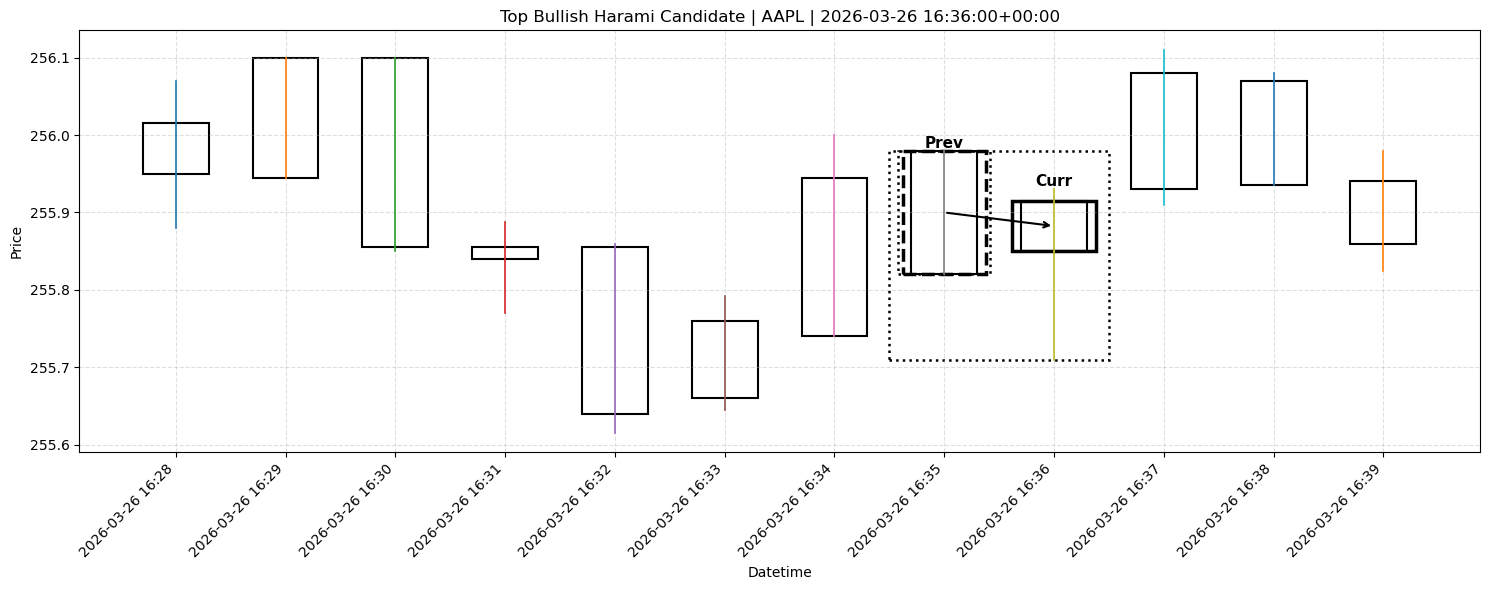

In [74]:
plot_bullish_harami_window(
    df_plot=plot_df,
    prev_idx=local_prev_idx,
    curr_idx=local_curr_idx,
    title=f"Top Bullish Harami Candidate | {top_ticker} | {top_time}",
)

Bearish Harami

In [75]:
from stock_analysis.candlestick_patterns.Bearish_Harami_Candlestick import BearishHaramiCandlestickPattern
from stock_analysis.tools.candlestick_utils import (
    add_candlestick_features,
    safe_ratio,
)

In [76]:
def explain_bearish_harami(df_window: pd.DataFrame) -> dict:
    df_feat = add_candlestick_features(df_window)

    prev = df_feat.iloc[-2]
    curr = df_feat.iloc[-1]

    prev_body_high = max(prev["Open"], prev["Close"])
    prev_body_low = min(prev["Open"], prev["Close"])
    curr_body_high = max(curr["Open"], curr["Close"])
    curr_body_low = min(curr["Open"], curr["Close"])

    prev_body_ratio = safe_ratio(prev["body"], prev["range"])
    curr_body_ratio = safe_ratio(curr["body"], curr["range"])
    size_ratio = safe_ratio(curr["body"], max(prev["body"], 1e-9))

    body_midpoint = (prev_body_high + prev_body_low) / 2
    centeredness = safe_ratio(
        min(curr_body_high - body_midpoint, body_midpoint - curr_body_low),
        max(prev["body"] / 2, 1e-9),
    )

    shape_ok = (
        prev["direction"] == "bullish"
        and curr["direction"] == "bearish"
        and prev_body_ratio >= 0.5
        and curr_body_ratio >= 0.15
        and curr_body_high < prev_body_high
        and curr_body_low > prev_body_low
        and size_ratio <= 0.65
    )

    return {
        "Prev_Datetime": prev["Datetime"] if "Datetime" in prev.index else None,
        "Curr_Datetime": curr["Datetime"] if "Datetime" in curr.index else None,

        "Prev_Open": prev["Open"],
        "Prev_High": prev["High"],
        "Prev_Low": prev["Low"],
        "Prev_Close": prev["Close"],
        "Prev_Direction": prev["direction"],
        "Prev_Body": prev["body"],
        "Prev_Range": prev["range"],
        "Prev_Body_Ratio": prev_body_ratio,

        "Curr_Open": curr["Open"],
        "Curr_High": curr["High"],
        "Curr_Low": curr["Low"],
        "Curr_Close": curr["Close"],
        "Curr_Direction": curr["direction"],
        "Curr_Body": curr["body"],
        "Curr_Range": curr["range"],
        "Curr_Body_Ratio": curr_body_ratio,

        "Prev_Body_High": prev_body_high,
        "Prev_Body_Low": prev_body_low,
        "Curr_Body_High": curr_body_high,
        "Curr_Body_Low": curr_body_low,

        "Size_Ratio_Curr_to_Prev": size_ratio,
        "Centeredness": centeredness,
        "Strict_Harami_Shape_OK": shape_ok,
    }

In [77]:
def plot_bearish_harami_window(
    df_plot: pd.DataFrame,
    prev_idx: int,
    curr_idx: int,
    title: str = "Bearish Harami Pattern",
):
    """
    Plot a bearish harami window.
    Shows structure only, without numeric annotations.
    """
    df_plot = df_plot.copy().reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(15, 6))
    x = np.arange(len(df_plot))
    candle_width = 0.6

    # 1. Draw all candlesticks
    for i, row in df_plot.iterrows():
        open_ = row["Open"]
        high_ = row["High"]
        low_ = row["Low"]
        close_ = row["Close"]

        ax.plot([i, i], [low_, high_], linewidth=1.2)

        body_low = min(open_, close_)
        body_height = abs(close_ - open_)

        rect = Rectangle(
            (i - candle_width / 2, body_low),
            candle_width,
            max(body_height, 0.001),
            fill=False,
            linewidth=1.5
        )
        ax.add_patch(rect)

    prev_row = df_plot.iloc[prev_idx]
    curr_row = df_plot.iloc[curr_idx]

    prev_body_low = min(prev_row["Open"], prev_row["Close"])
    prev_body_high = max(prev_row["Open"], prev_row["Close"])
    curr_body_low = min(curr_row["Open"], curr_row["Close"])
    curr_body_high = max(curr_row["Open"], curr_row["Close"])

    # 2. Highlight previous large candle
    prev_highlight = Rectangle(
        (prev_idx - candle_width / 2 - 0.08, prev_body_low),
        candle_width + 0.16,
        max(prev_body_high - prev_body_low, 0.001),
        fill=False,
        linewidth=2.5,
        linestyle="--"
    )
    ax.add_patch(prev_highlight)

    ax.text(
        prev_idx,
        prev_row["High"],
        "Prev",
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="bottom"
    )

    # 3. Highlight current small candle
    curr_highlight = Rectangle(
        (curr_idx - candle_width / 2 - 0.08, curr_body_low),
        candle_width + 0.16,
        max(curr_body_high - curr_body_low, 0.001),
        fill=False,
        linewidth=2.5
    )
    ax.add_patch(curr_highlight)

    ax.text(
        curr_idx,
        curr_row["High"],
        "Curr",
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="bottom"
    )

    # 4. Mother-body zone (body only)
    mother_box = Rectangle(
        (prev_idx - candle_width / 2 - 0.12, prev_body_low),
        candle_width + 0.24,
        max(prev_body_high - prev_body_low, 0.001),
        fill=False,
        linewidth=1.8,
        linestyle=":"
    )
    ax.add_patch(mother_box)

    # 5. Outer frame around the pair
    left_edge = prev_idx - candle_width / 2 - 0.2
    right_edge = curr_idx + candle_width / 2 + 0.2
    bottom_edge = min(prev_row["Low"], curr_row["Low"], prev_body_low, curr_body_low)
    top_edge = max(prev_row["High"], curr_row["High"], prev_body_high, curr_body_high)

    outer_box = Rectangle(
        (left_edge, bottom_edge),
        right_edge - left_edge,
        top_edge - bottom_edge,
        fill=False,
        linewidth=1.8,
        linestyle=":"
    )
    ax.add_patch(outer_box)

    # 6. Arrow showing containment relationship
    ax.annotate(
        "",
        xy=(curr_idx, (curr_body_low + curr_body_high) / 2),
        xytext=(prev_idx, (prev_body_low + prev_body_high) / 2),
        arrowprops=dict(arrowstyle="->", lw=1.5)
    )

    # 7. Axes / labels
    ax.set_xticks(x)
    ax.set_xticklabels(
        [str(pd.to_datetime(dt))[:16] for dt in df_plot["Datetime"]],
        rotation=45,
        ha="right"
    )

    ax.set_title(title)
    ax.set_xlabel("Datetime")
    ax.set_ylabel("Price")
    ax.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

In [78]:
pattern = BearishHaramiCandlestickPattern()
window_size = 2

bearish_harami_results = scan_all_candlestick_patterns(
    df_all=df_long,
    pattern=pattern,
    window_size=window_size,
)

print("Total detected Bearish Harami patterns:", len(bearish_harami_results))

if bearish_harami_results.empty:
    print("No Bearish Harami patterns detected.")
else:
    print("\nCounts by ticker:")
    print(bearish_harami_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        bearish_harami_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 2
Scanning tickers: ['AAPL', 'AMZN', 'MSFT', 'NVDA', 'TSLA']
Total detected Bearish Harami patterns: 286

Counts by ticker:
Ticker
TSLA    65
AMZN    62
MSFT    61
AAPL    58
NVDA    40
Name: count, dtype: int64

Top 20 by confidence:


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
16,AAPL,2026-03-27 18:46:00+00:00,BearishHaramiCandlestickPattern,candlestick,85.0,703,704
34,AAPL,2026-04-01 14:43:00+00:00,BearishHaramiCandlestickPattern,candlestick,85.0,1630,1631
44,AAPL,2026-04-01 19:10:00+00:00,BearishHaramiCandlestickPattern,candlestick,83.0,1897,1898
231,TSLA,2026-03-26 17:35:00+00:00,BearishHaramiCandlestickPattern,candlestick,83.0,244,245
0,AAPL,2026-03-26 14:12:00+00:00,BearishHaramiCandlestickPattern,candlestick,80.0,41,42
1,AAPL,2026-03-26 14:23:00+00:00,BearishHaramiCandlestickPattern,candlestick,80.0,52,53
2,AAPL,2026-03-26 15:52:00+00:00,BearishHaramiCandlestickPattern,candlestick,80.0,141,142
3,AAPL,2026-03-26 17:27:00+00:00,BearishHaramiCandlestickPattern,candlestick,80.0,236,237
6,AAPL,2026-03-26 18:37:00+00:00,BearishHaramiCandlestickPattern,candlestick,80.0,306,307
10,AAPL,2026-03-27 16:03:00+00:00,BearishHaramiCandlestickPattern,candlestick,80.0,540,541


In [79]:
if bearish_harami_results.empty:
    print("No Bearish Harami patterns found, cannot select top candidate.")
else:
    top_bearish_harami = (
        bearish_harami_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Bearish Harami candidate:")
    print(top_bearish_harami)

    top_ticker = top_bearish_harami["Ticker"]
    top_start_idx = int(top_bearish_harami["WindowStartIdx"])
    top_end_idx = int(top_bearish_harami["WindowEndIdx"])
    top_time = top_bearish_harami["Datetime"]

    print("\nSelected ticker:", top_ticker)
    print("Window:", top_start_idx, "to", top_end_idx)
    print("Event time:", top_time)

Top Bearish Harami candidate:
Ticker                                       AAPL
Datetime                2026-03-27 18:46:00+00:00
Pattern           BearishHaramiCandlestickPattern
Category                              candlestick
Confidence                                   85.0
WindowStartIdx                                703
WindowEndIdx                                  704
Name: 16, dtype: object

Selected ticker: AAPL
Window: 703 to 704
Event time: 2026-03-27 18:46:00+00:00


In [80]:
plot_df, _ = extract_pattern_context(
    df_all=df_long,
    ticker=top_ticker,
    event_idx=top_end_idx,
    left_context=8,
    right_context=3,
)

print("Plot window shape:", plot_df.shape)
display(plot_df.head())
display(plot_df.tail())

Plot window shape: (12, 6)


Price,Datetime,Ticker,Open,High,Low,Close
0,2026-03-27 18:38:00+00:00,AAPL,249.360001,249.360001,249.100006,249.139999
1,2026-03-27 18:39:00+00:00,AAPL,249.130005,249.269897,248.945007,249.000000
2,2026-03-27 18:40:00+00:00,AAPL,249.020004,249.039993,248.830002,248.919998
3,2026-03-27 18:41:00+00:00,AAPL,248.925003,249.009995,248.820007,248.839996
4,2026-03-27 18:42:00+00:00,AAPL,248.839996,248.850006,248.610001,248.780106


Price,Datetime,Ticker,Open,High,Low,Close
7,2026-03-27 18:45:00+00:00,AAPL,248.889999,249.044998,248.880005,249.014999
8,2026-03-27 18:46:00+00:00,AAPL,249.000000,249.059998,248.860001,248.940002
9,2026-03-27 18:47:00+00:00,AAPL,248.929993,248.970001,248.809998,248.820007
10,2026-03-27 18:48:00+00:00,AAPL,248.800201,248.979996,248.789993,248.940002
11,2026-03-27 18:49:00+00:00,AAPL,248.929993,249.089996,248.919998,249.000000


In [81]:
df_ticker_full = (
    df_long[df_long["Ticker"] == top_ticker]
    .sort_values("Datetime")
    .reset_index(drop=True)
    .copy()
)

harami_window_df = df_ticker_full.iloc[top_start_idx:top_end_idx + 1].reset_index(drop=True)

print("Bearish Harami 2-candle window:")
display(harami_window_df)

Bearish Harami 2-candle window:


Price,Datetime,Ticker,Open,High,Low,Close
0,2026-03-27 18:45:00+00:00,AAPL,248.889999,249.044998,248.880005,249.014999
1,2026-03-27 18:46:00+00:00,AAPL,249.000000,249.059998,248.860001,248.940002


In [82]:
bearish_harami_explanation = explain_bearish_harami(harami_window_df)

print("Extracted Bearish Harami explanation:")
for k, v in bearish_harami_explanation.items():
    print(f"{k}: {v}")

Extracted Bearish Harami explanation:
Prev_Datetime: 2026-03-27 18:45:00+00:00
Curr_Datetime: 2026-03-27 18:46:00+00:00
Prev_Open: 248.88999938964844
Prev_High: 249.0449981689453
Prev_Low: 248.8800048828125
Prev_Close: 249.01499938964844
Prev_Direction: bullish
Prev_Body: 0.125
Prev_Range: 0.1649932861328125
Prev_Body_Ratio: 0.757606584666605
Curr_Open: 249.0
Curr_High: 249.05999755859375
Curr_Low: 248.86000061035156
Curr_Close: 248.94000244140625
Curr_Direction: bearish
Curr_Body: 0.05999755859375
Curr_Range: 0.1999969482421875
Curr_Body_Ratio: 0.29999237048905164
Prev_Body_High: 249.01499938964844
Prev_Body_Low: 248.88999938964844
Curr_Body_High: 249.0
Curr_Body_Low: 248.94000244140625
Size_Ratio_Curr_to_Prev: 0.47998046875
Centeredness: 0.199951171875
Strict_Harami_Shape_OK: True


In [83]:
bearish_harami_explanation_df = pd.DataFrame([bearish_harami_explanation])
display(bearish_harami_explanation_df)

,Prev_Datetime,Curr_Datetime,Prev_Open,Prev_High,Prev_Low,Prev_Close,Prev_Direction,Prev_Body,Prev_Range,Prev_Body_Ratio,...,Curr_Body,Curr_Range,Curr_Body_Ratio,Prev_Body_High,Prev_Body_Low,Curr_Body_High,Curr_Body_Low,Size_Ratio_Curr_to_Prev,Centeredness,Strict_Harami_Shape_OK
0,2026-03-27 18:45:00+00:00,2026-03-27 18:46:00+00:00,248.889999,249.044998,248.880005,249.014999,bullish,0.125,0.164993,0.757607,...,0.059998,0.199997,0.299992,249.014999,248.889999,249.0,248.940002,0.47998,0.199951,True


In [84]:
local_prev_idx, local_curr_idx = get_local_indices_for_multi_candle_pattern(
    plot_df=plot_df,
    full_df_ticker=df_ticker_full,
    start_idx=top_start_idx,
    end_idx=top_end_idx,
)

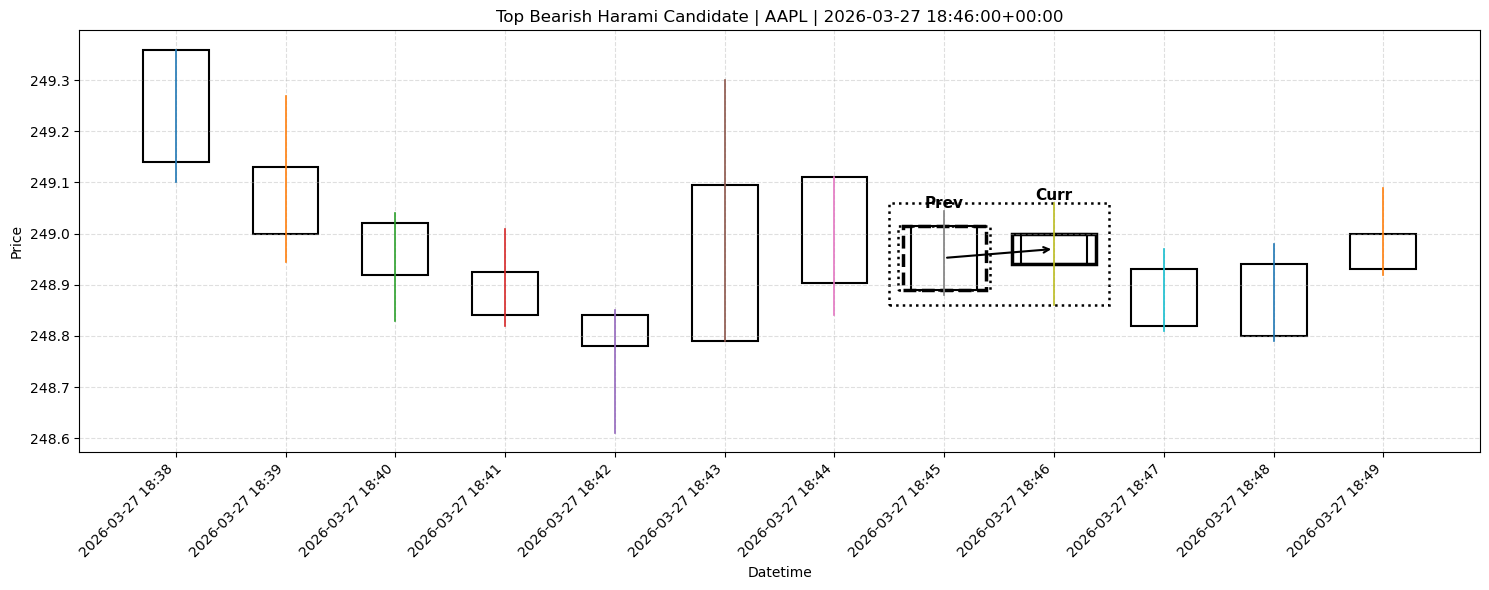

In [85]:
plot_bearish_harami_window(
    df_plot=plot_df,
    prev_idx=local_prev_idx,
    curr_idx=local_curr_idx,
    title=f"Top Bearish Harami Candidate | {top_ticker} | {top_time}",
)

Morning Star Pattern

In [86]:
from stock_analysis.candlestick_patterns.Morning_Star_Candlestick import MorningStarCandlestickPattern
from stock_analysis.tools.candlestick_utils import (
    add_candlestick_features,
    safe_ratio,
)

In [87]:
def explain_morning_star(df_window: pd.DataFrame) -> dict:
    df_feat = add_candlestick_features(df_window)

    c1 = df_feat.iloc[-3]
    c2 = df_feat.iloc[-2]
    c3 = df_feat.iloc[-1]

    c1_body_ratio = safe_ratio(c1["body"], c1["range"])
    c2_body_ratio = safe_ratio(c2["body"], c2["range"])
    c3_body_ratio = safe_ratio(c3["body"], c3["range"])

    first_bearish = c1["direction"] == "bearish"
    last_bullish = c3["direction"] == "bullish"

    midpoint_c1 = (c1["Open"] + c1["Close"]) / 2
    recovery_ok = c3["Close"] >= midpoint_c1

    middle_smaller_than_neighbors = (
        c2["body"] < c1["body"] and c2["body"] < c3["body"]
    )

    strong_edges = c1_body_ratio >= 0.45 and c3_body_ratio >= 0.45

    middle_anchor_ok = (
        max(c2["Open"], c2["Close"]) <= max(c1["Open"], c1["Close"])
        and min(c2["Open"], c2["Close"]) <= max(c1["Open"], c1["Close"])
    )

    c1_body = abs(c1["Open"] - c1["Close"])
    recovery_depth = c3["Close"] - c1["Close"]
    recovery_ratio = safe_ratio(recovery_depth, c1_body)

    shape_ok = (
        first_bearish
        and c2_body_ratio <= 0.25
        and last_bullish
        and middle_smaller_than_neighbors
        and strong_edges
        and recovery_ok
        and middle_anchor_ok
    )

    return {
        "C1_Datetime": c1["Datetime"] if "Datetime" in c1.index else None,
        "C2_Datetime": c2["Datetime"] if "Datetime" in c2.index else None,
        "C3_Datetime": c3["Datetime"] if "Datetime" in c3.index else None,

        "C1_Open": c1["Open"],
        "C1_Close": c1["Close"],
        "C1_High": c1["High"],
        "C1_Low": c1["Low"],
        "C1_Direction": c1["direction"],
        "C1_Body": c1["body"],
        "C1_Range": c1["range"],
        "C1_Body_Ratio": c1_body_ratio,

        "C2_Open": c2["Open"],
        "C2_Close": c2["Close"],
        "C2_High": c2["High"],
        "C2_Low": c2["Low"],
        "C2_Direction": c2["direction"],
        "C2_Body": c2["body"],
        "C2_Range": c2["range"],
        "C2_Body_Ratio": c2_body_ratio,

        "C3_Open": c3["Open"],
        "C3_Close": c3["Close"],
        "C3_High": c3["High"],
        "C3_Low": c3["Low"],
        "C3_Direction": c3["direction"],
        "C3_Body": c3["body"],
        "C3_Range": c3["range"],
        "C3_Body_Ratio": c3_body_ratio,

        "First_Bearish": first_bearish,
        "Last_Bullish": last_bullish,
        "Middle_Smaller_Than_Neighbors": middle_smaller_than_neighbors,
        "Strong_Edges": strong_edges,
        "Midpoint_C1": midpoint_c1,
        "Recovery_OK": recovery_ok,
        "Recovery_Ratio": recovery_ratio,
        "Middle_Anchor_OK": middle_anchor_ok,
        "Strict_Morning_Star_Shape_OK": shape_ok,
    }

In [88]:
def plot_morning_star_window(
    df_plot: pd.DataFrame,
    c1_idx: int,
    c2_idx: int,
    c3_idx: int,
    title: str = "Morning Star Pattern",
):
    """
    Plot a morning star window with three highlighted candles.
    Structure only, no numeric labels.
    """
    df_plot = df_plot.copy().reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(15, 6))
    x = np.arange(len(df_plot))
    candle_width = 0.6

    # 1. Draw all candles
    for i, row in df_plot.iterrows():
        open_ = row["Open"]
        high_ = row["High"]
        low_ = row["Low"]
        close_ = row["Close"]

        ax.plot([i, i], [low_, high_], linewidth=1.2)

        body_low = min(open_, close_)
        body_height = abs(close_ - open_)

        rect = Rectangle(
            (i - candle_width / 2, body_low),
            candle_width,
            max(body_height, 0.001),
            fill=False,
            linewidth=1.5
        )
        ax.add_patch(rect)

    c1 = df_plot.iloc[c1_idx]
    c2 = df_plot.iloc[c2_idx]
    c3 = df_plot.iloc[c3_idx]

    c1_body_low = min(c1["Open"], c1["Close"])
    c1_body_high = max(c1["Open"], c1["Close"])
    c2_body_low = min(c2["Open"], c2["Close"])
    c2_body_high = max(c2["Open"], c2["Close"])
    c3_body_low = min(c3["Open"], c3["Close"])
    c3_body_high = max(c3["Open"], c3["Close"])

    # 2. Highlight c1
    rect1 = Rectangle(
        (c1_idx - candle_width / 2 - 0.08, c1_body_low),
        candle_width + 0.16,
        max(c1_body_high - c1_body_low, 0.001),
        fill=False,
        linewidth=2.5,
        linestyle="--"
    )
    ax.add_patch(rect1)
    ax.text(c1_idx, c1["High"], "C1", fontsize=11, fontweight="bold",
            ha="center", va="bottom")

    # 3. Highlight c2
    rect2 = Rectangle(
        (c2_idx - candle_width / 2 - 0.08, c2_body_low),
        candle_width + 0.16,
        max(c2_body_high - c2_body_low, 0.001),
        fill=False,
        linewidth=2.5,
    )
    ax.add_patch(rect2)
    ax.text(c2_idx, c2["High"], "C2", fontsize=11, fontweight="bold",
            ha="center", va="bottom")

    # 4. Highlight c3
    rect3 = Rectangle(
        (c3_idx - candle_width / 2 - 0.08, c3_body_low),
        candle_width + 0.16,
        max(c3_body_high - c3_body_low, 0.001),
        fill=False,
        linewidth=2.5,
    )
    ax.add_patch(rect3)
    ax.text(c3_idx, c3["High"], "C3", fontsize=11, fontweight="bold",
            ha="center", va="bottom")

    # 5. Outer frame around three-candle pattern
    left_edge = c1_idx - candle_width / 2 - 0.2
    right_edge = c3_idx + candle_width / 2 + 0.2
    bottom_edge = min(c1["Low"], c2["Low"], c3["Low"],
                      c1_body_low, c2_body_low, c3_body_low)
    top_edge = max(c1["High"], c2["High"], c3["High"],
                   c1_body_high, c2_body_high, c3_body_high)

    outer_box = Rectangle(
        (left_edge, bottom_edge),
        right_edge - left_edge,
        top_edge - bottom_edge,
        fill=False,
        linewidth=1.8,
        linestyle=":"
    )
    ax.add_patch(outer_box)

    # 6. Draw midpoint line of c1 body
    midpoint_c1 = (c1["Open"] + c1["Close"]) / 2
    ax.hlines(
        y=midpoint_c1,
        xmin=c1_idx - 0.35,
        xmax=c3_idx + 0.35,
        linestyles="--",
        linewidth=1.2
    )

    # 7. Draw arrows showing progression
    ax.annotate(
        "",
        xy=(c2_idx, (c2_body_low + c2_body_high) / 2),
        xytext=(c1_idx, (c1_body_low + c1_body_high) / 2),
        arrowprops=dict(arrowstyle="->", lw=1.3)
    )
    ax.annotate(
        "",
        xy=(c3_idx, (c3_body_low + c3_body_high) / 2),
        xytext=(c2_idx, (c2_body_low + c2_body_high) / 2),
        arrowprops=dict(arrowstyle="->", lw=1.3)
    )

    # 8. Axes
    ax.set_xticks(x)
    ax.set_xticklabels(
        [str(pd.to_datetime(dt))[:16] for dt in df_plot["Datetime"]],
        rotation=45,
        ha="right"
    )

    ax.set_title(title)
    ax.set_xlabel("Datetime")
    ax.set_ylabel("Price")
    ax.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

In [89]:
def get_local_indices_for_three_candle_pattern(
    plot_df: pd.DataFrame,
    full_df_ticker: pd.DataFrame,
    start_idx: int,
    end_idx: int,
):
    """
    Convert full ticker indices for a 3-candle pattern
    into local indices inside plot_df.
    """
    plot_times = list(plot_df["Datetime"])
    full_times = list(full_df_ticker.iloc[start_idx:end_idx + 1]["Datetime"])

    local_indices = []
    for t in full_times:
        local_indices.append(plot_times.index(t))

    return local_indices  # [c1_idx, c2_idx, c3_idx]

In [90]:
pattern = MorningStarCandlestickPattern()
window_size = 3

morning_star_results = scan_all_candlestick_patterns(
    df_all=df_long,
    pattern=pattern,
    window_size=window_size,
)

print("Total detected Morning Star patterns:", len(morning_star_results))

if morning_star_results.empty:
    print("No Morning Star patterns detected.")
else:
    print("\nCounts by ticker:")
    print(morning_star_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        morning_star_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 3
Scanning tickers: ['AAPL', 'AMZN', 'MSFT', 'NVDA', 'TSLA']
Total detected Morning Star patterns: 183

Counts by ticker:
Ticker
AMZN    41
MSFT    39
AAPL    37
NVDA    36
TSLA    30
Name: count, dtype: int64

Top 20 by confidence:


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
3,AAPL,2026-03-26 18:00:00+00:00,MorningStarCandlestickPattern,candlestick,100.0,268,270
4,AAPL,2026-03-27 13:45:00+00:00,MorningStarCandlestickPattern,candlestick,100.0,403,405
6,AAPL,2026-03-27 15:28:00+00:00,MorningStarCandlestickPattern,candlestick,100.0,504,506
8,AAPL,2026-03-27 17:50:00+00:00,MorningStarCandlestickPattern,candlestick,100.0,646,648
13,AAPL,2026-03-30 15:32:00+00:00,MorningStarCandlestickPattern,candlestick,100.0,898,900
26,AAPL,2026-04-01 19:05:00+00:00,MorningStarCandlestickPattern,candlestick,100.0,1891,1893
27,AAPL,2026-04-01 19:34:00+00:00,MorningStarCandlestickPattern,candlestick,100.0,1920,1922
32,AAPL,2026-04-02 17:53:00+00:00,MorningStarCandlestickPattern,candlestick,100.0,2209,2211
45,AMZN,2026-03-27 17:06:00+00:00,MorningStarCandlestickPattern,candlestick,100.0,602,604
57,AMZN,2026-03-30 19:50:00+00:00,MorningStarCandlestickPattern,candlestick,100.0,1156,1158


In [91]:
if morning_star_results.empty:
    print("No Morning Star patterns found, cannot select top candidate.")
else:
    top_morning_star = (
        morning_star_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Morning Star candidate:")
    print(top_morning_star)

    top_ticker = top_morning_star["Ticker"]
    top_start_idx = int(top_morning_star["WindowStartIdx"])
    top_end_idx = int(top_morning_star["WindowEndIdx"])
    top_time = top_morning_star["Datetime"]

    print("\nSelected ticker:", top_ticker)
    print("Window:", top_start_idx, "to", top_end_idx)
    print("Event time:", top_time)

Top Morning Star candidate:
Ticker                                     AAPL
Datetime              2026-03-26 18:00:00+00:00
Pattern           MorningStarCandlestickPattern
Category                            candlestick
Confidence                                100.0
WindowStartIdx                              268
WindowEndIdx                                270
Name: 3, dtype: object

Selected ticker: AAPL
Window: 268 to 270
Event time: 2026-03-26 18:00:00+00:00


In [92]:
plot_df, _ = extract_pattern_context(
    df_all=df_long,
    ticker=top_ticker,
    event_idx=top_end_idx,
    left_context=8,
    right_context=3,
)

print("Plot window shape:", plot_df.shape)
display(plot_df.head())
display(plot_df.tail())

Plot window shape: (12, 6)


Price,Datetime,Ticker,Open,High,Low,Close
0,2026-03-26 17:52:00+00:00,AAPL,254.255005,254.309998,254.190002,254.199997
1,2026-03-26 17:53:00+00:00,AAPL,254.199997,254.210007,253.940002,254.074997
2,2026-03-26 17:54:00+00:00,AAPL,254.095001,254.110001,253.960007,254.000000
3,2026-03-26 17:55:00+00:00,AAPL,253.990005,254.235001,253.960007,254.190002
4,2026-03-26 17:56:00+00:00,AAPL,254.169998,254.229996,254.070007,254.080002


Price,Datetime,Ticker,Open,High,Low,Close
7,2026-03-26 17:59:00+00:00,AAPL,253.789993,253.830002,253.660995,253.804993
8,2026-03-26 18:00:00+00:00,AAPL,253.789993,254.130005,253.750000,254.059998
9,2026-03-26 18:01:00+00:00,AAPL,254.070007,254.475006,254.070007,254.464996
10,2026-03-26 18:02:00+00:00,AAPL,254.470001,254.669998,254.440002,254.596802
11,2026-03-26 18:03:00+00:00,AAPL,254.610001,254.699997,254.330002,254.400101


In [93]:
df_ticker_full = (
    df_long[df_long["Ticker"] == top_ticker]
    .sort_values("Datetime")
    .reset_index(drop=True)
    .copy()
)

morning_star_window_df = df_ticker_full.iloc[top_start_idx:top_end_idx + 1].reset_index(drop=True)

print("Morning Star 3-candle window:")
display(morning_star_window_df)

Morning Star 3-candle window:


Price,Datetime,Ticker,Open,High,Low,Close
0,2026-03-26 17:58:00+00:00,AAPL,254.009995,254.020004,253.764999,253.800003
1,2026-03-26 17:59:00+00:00,AAPL,253.789993,253.830002,253.660995,253.804993
2,2026-03-26 18:00:00+00:00,AAPL,253.789993,254.130005,253.750000,254.059998


In [94]:
morning_star_explanation = explain_morning_star(morning_star_window_df)

print("Extracted Morning Star explanation:")
for k, v in morning_star_explanation.items():
    print(f"{k}: {v}")

Extracted Morning Star explanation:
C1_Datetime: 2026-03-26 17:58:00+00:00
C2_Datetime: 2026-03-26 17:59:00+00:00
C3_Datetime: 2026-03-26 18:00:00+00:00
C1_Open: 254.00999450683594
C1_Close: 253.8000030517578
C1_High: 254.02000427246094
C1_Low: 253.76499938964844
C1_Direction: bearish
C1_Body: 0.209991455078125
C1_Range: 0.2550048828125
C1_Body_Ratio: 0.8234801340354236
C2_Open: 253.7899932861328
C2_Close: 253.80499267578125
C2_High: 253.8300018310547
C2_Low: 253.66099548339844
C2_Direction: bullish
C2_Body: 0.0149993896484375
C2_Range: 0.16900634765625
C2_Body_Ratio: 0.08875045142650777
C3_Open: 253.7899932861328
C3_Close: 254.05999755859375
C3_High: 254.1300048828125
C3_Low: 253.75
C3_Direction: bullish
C3_Body: 0.2700042724609375
C3_Range: 0.3800048828125
C3_Body_Ratio: 0.7105284291680052
First_Bearish: True
Last_Bullish: True
Middle_Smaller_Than_Neighbors: True
Strong_Edges: True
Midpoint_C1: 253.90499877929688
Recovery_OK: True
Recovery_Ratio: 1.238119459380904
Middle_Anchor_OK: T

In [95]:
morning_star_explanation_df = pd.DataFrame([morning_star_explanation])
display(morning_star_explanation_df)

,C1_Datetime,C2_Datetime,C3_Datetime,C1_Open,C1_Close,C1_High,C1_Low,C1_Direction,C1_Body,C1_Range,...,C3_Body_Ratio,First_Bearish,Last_Bullish,Middle_Smaller_Than_Neighbors,Strong_Edges,Midpoint_C1,Recovery_OK,Recovery_Ratio,Middle_Anchor_OK,Strict_Morning_Star_Shape_OK
0,2026-03-26 17:58:00+00:00,2026-03-26 17:59:00+00:00,2026-03-26 18:00:00+00:00,254.009995,253.800003,254.020004,253.764999,bearish,0.209991,0.255005,...,0.710528,True,True,True,True,253.904999,True,1.238119,True,True


In [96]:
local_c1_idx, local_c2_idx, local_c3_idx = get_local_indices_for_three_candle_pattern(
    plot_df=plot_df,
    full_df_ticker=df_ticker_full,
    start_idx=top_start_idx,
    end_idx=top_end_idx,
)

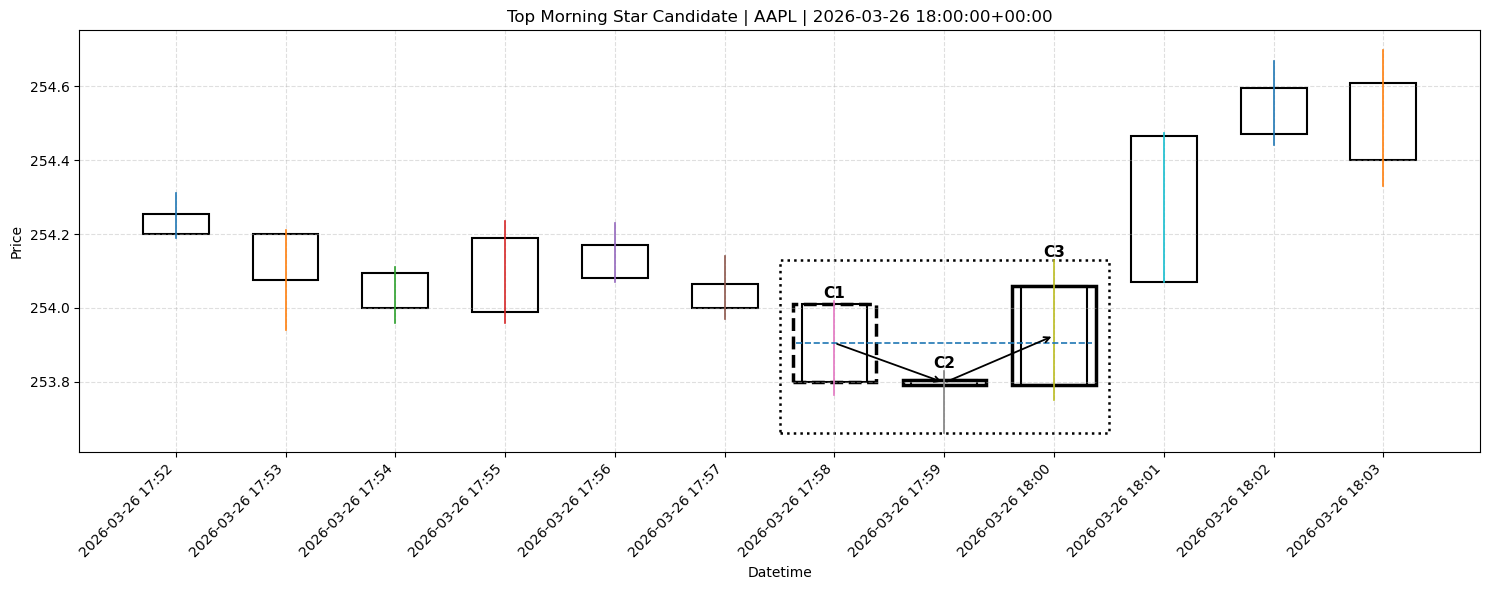

In [97]:
plot_morning_star_window(
    df_plot=plot_df,
    c1_idx=local_c1_idx,
    c2_idx=local_c2_idx,
    c3_idx=local_c3_idx,
    title=f"Top Morning Star Candidate | {top_ticker} | {top_time}",
)

Evening Star Pattern

In [98]:
from stock_analysis.candlestick_patterns.Evening_Star_Candlestick import EveningStarCandlestickPattern
from stock_analysis.tools.candlestick_utils import (
    add_candlestick_features,
    safe_ratio,
)

In [99]:
def explain_evening_star(df_window: pd.DataFrame) -> dict:
    df_feat = add_candlestick_features(df_window)

    c1 = df_feat.iloc[-3]
    c2 = df_feat.iloc[-2]
    c3 = df_feat.iloc[-1]

    c1_body_ratio = safe_ratio(c1["body"], c1["range"])
    c2_body_ratio = safe_ratio(c2["body"], c2["range"])
    c3_body_ratio = safe_ratio(c3["body"], c3["range"])

    midpoint_c1 = (c1["Open"] + c1["Close"]) / 2
    recovery_ok = c3["Close"] <= midpoint_c1
    middle_smaller_than_neighbors = (
        c2["body"] < c1["body"] and c2["body"] < c3["body"]
    )
    strong_edges = c1_body_ratio >= 0.45 and c3_body_ratio >= 0.45

    c1_body = abs(c1["Close"] - c1["Open"])
    reversal_depth = c1["Close"] - c3["Close"]
    reversal_ratio = safe_ratio(reversal_depth, c1_body)

    shape_ok = (
        c1["direction"] == "bullish"
        and c2_body_ratio <= 0.3
        and c3["direction"] == "bearish"
        and recovery_ok
        and middle_smaller_than_neighbors
        and strong_edges
    )

    return {
        "C1_Datetime": c1["Datetime"] if "Datetime" in c1.index else None,
        "C2_Datetime": c2["Datetime"] if "Datetime" in c2.index else None,
        "C3_Datetime": c3["Datetime"] if "Datetime" in c3.index else None,

        "C1_Open": c1["Open"],
        "C1_Close": c1["Close"],
        "C1_High": c1["High"],
        "C1_Low": c1["Low"],
        "C1_Direction": c1["direction"],
        "C1_Body": c1["body"],
        "C1_Range": c1["range"],
        "C1_Body_Ratio": c1_body_ratio,

        "C2_Open": c2["Open"],
        "C2_Close": c2["Close"],
        "C2_High": c2["High"],
        "C2_Low": c2["Low"],
        "C2_Direction": c2["direction"],
        "C2_Body": c2["body"],
        "C2_Range": c2["range"],
        "C2_Body_Ratio": c2_body_ratio,

        "C3_Open": c3["Open"],
        "C3_Close": c3["Close"],
        "C3_High": c3["High"],
        "C3_Low": c3["Low"],
        "C3_Direction": c3["direction"],
        "C3_Body": c3["body"],
        "C3_Range": c3["range"],
        "C3_Body_Ratio": c3_body_ratio,

        "Midpoint_C1": midpoint_c1,
        "Recovery_OK": recovery_ok,
        "Reversal_Ratio": reversal_ratio,
        "First_Bullish": c1["direction"] == "bullish",
        "Last_Bearish": c3["direction"] == "bearish",
        "Middle_Smaller_Than_Neighbors": middle_smaller_than_neighbors,
        "Strong_Edges": strong_edges,
        "Strict_Evening_Star_Shape_OK": shape_ok,
    }

In [100]:
def plot_evening_star_window(
    df_plot: pd.DataFrame,
    c1_idx: int,
    c2_idx: int,
    c3_idx: int,
    title: str = "Evening Star Pattern",
):
    df_plot = df_plot.copy().reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(15, 6))
    x = np.arange(len(df_plot))
    candle_width = 0.6

    # 1. draw all candlesticks
    for i, row in df_plot.iterrows():
        open_ = row["Open"]
        high_ = row["High"]
        low_ = row["Low"]
        close_ = row["Close"]

        ax.plot([i, i], [low_, high_], linewidth=1.2)

        body_low = min(open_, close_)
        body_height = abs(close_ - open_)

        rect = Rectangle(
            (i - candle_width / 2, body_low),
            candle_width,
            max(body_height, 0.001),
            fill=False,
            linewidth=1.5
        )
        ax.add_patch(rect)

    r1 = df_plot.iloc[c1_idx]
    r2 = df_plot.iloc[c2_idx]
    r3 = df_plot.iloc[c3_idx]

    def add_body_highlight(idx, row, label, linestyle="-"):
        body_low = min(row["Open"], row["Close"])
        body_high = max(row["Open"], row["Close"])

        rect = Rectangle(
            (idx - candle_width / 2 - 0.08, body_low),
            candle_width + 0.16,
            max(body_high - body_low, 0.001),
            fill=False,
            linewidth=2.5,
            linestyle=linestyle
        )
        ax.add_patch(rect)

        ax.text(
            idx,
            row["High"],
            label,
            fontsize=11,
            fontweight="bold",
            ha="center",
            va="bottom"
        )

    add_body_highlight(c1_idx, r1, "C1", linestyle="--")
    add_body_highlight(c2_idx, r2, "C2", linestyle=":")
    add_body_highlight(c3_idx, r3, "C3", linestyle="-")

    # 3. outer frame
    left_edge = c1_idx - candle_width / 2 - 0.2
    right_edge = c3_idx + candle_width / 2 + 0.2
    bottom_edge = min(r1["Low"], r2["Low"], r3["Low"])
    top_edge = max(r1["High"], r2["High"], r3["High"])

    outer_box = Rectangle(
        (left_edge, bottom_edge),
        right_edge - left_edge,
        top_edge - bottom_edge,
        fill=False,
        linewidth=1.8,
        linestyle=":"
    )
    ax.add_patch(outer_box)

    # 4. midpoint of first candle body
    midpoint_c1 = (r1["Open"] + r1["Close"]) / 2
    ax.hlines(
        y=midpoint_c1,
        xmin=c1_idx - 0.4,
        xmax=c3_idx + 0.4,
        linestyles="--",
        linewidth=1.3
    )

    ax.text(
        c3_idx + 0.45,
        midpoint_c1,
        "C1 midpoint",
        fontsize=10,
        va="center"
    )

    # 5. reversal arrow from c2 toward c3
    ax.annotate(
        "",
        xy=(c3_idx, (min(r3["Open"], r3["Close"]) + max(r3["Open"], r3["Close"])) / 2),
        xytext=(c2_idx, (min(r2["Open"], r2["Close"]) + max(r2["Open"], r2["Close"])) / 2),
        arrowprops=dict(arrowstyle="->", lw=1.5)
    )

    # 6. axes / labels
    ax.set_xticks(x)
    ax.set_xticklabels(
        [str(pd.to_datetime(dt))[:16] for dt in df_plot["Datetime"]],
        rotation=45,
        ha="right"
    )

    ax.set_title(title)
    ax.set_xlabel("Datetime")
    ax.set_ylabel("Price")
    ax.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

In [101]:
pattern = EveningStarCandlestickPattern()
window_size = 3

evening_star_results = scan_all_candlestick_patterns(
    df_all=df_long,
    pattern=pattern,
    window_size=window_size,
)

print("Total detected Evening Star patterns:", len(evening_star_results))

if evening_star_results.empty:
    print("No Evening Star patterns detected.")
else:
    print("\nCounts by ticker:")
    print(evening_star_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        evening_star_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 3
Scanning tickers: ['AAPL', 'AMZN', 'MSFT', 'NVDA', 'TSLA']
Total detected Evening Star patterns: 209

Counts by ticker:
Ticker
AAPL    50
TSLA    48
MSFT    45
NVDA    34
AMZN    32
Name: count, dtype: int64

Top 20 by confidence:


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
3,AAPL,2026-03-26 16:03:00+00:00,EveningStarCandlestickPattern,candlestick,100.0,151,153
9,AAPL,2026-03-27 13:56:00+00:00,EveningStarCandlestickPattern,candlestick,100.0,414,416
41,AAPL,2026-04-01 19:50:00+00:00,EveningStarCandlestickPattern,candlestick,100.0,1936,1938
50,AMZN,2026-03-26 13:38:00+00:00,EveningStarCandlestickPattern,candlestick,100.0,6,8
87,MSFT,2026-03-26 19:25:00+00:00,EveningStarCandlestickPattern,candlestick,100.0,353,355
101,MSFT,2026-03-31 14:25:00+00:00,EveningStarCandlestickPattern,candlestick,100.0,1221,1223
111,MSFT,2026-04-01 15:14:00+00:00,EveningStarCandlestickPattern,candlestick,100.0,1660,1662
118,MSFT,2026-04-01 19:07:00+00:00,EveningStarCandlestickPattern,candlestick,100.0,1893,1895
158,NVDA,2026-04-02 14:46:00+00:00,EveningStarCandlestickPattern,candlestick,100.0,2022,2024
181,TSLA,2026-03-30 17:46:00+00:00,EveningStarCandlestickPattern,candlestick,100.0,1032,1034


In [102]:
if evening_star_results.empty:
    print("No Evening Star patterns found, cannot select top candidate.")
else:
    top_evening_star = (
        evening_star_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Evening Star candidate:")
    print(top_evening_star)

    top_ticker = top_evening_star["Ticker"]
    top_start_idx = int(top_evening_star["WindowStartIdx"])
    top_end_idx = int(top_evening_star["WindowEndIdx"])
    top_time = top_evening_star["Datetime"]

    print("\nSelected ticker:", top_ticker)
    print("Window:", top_start_idx, "to", top_end_idx)
    print("Event time:", top_time)

Top Evening Star candidate:
Ticker                                     AAPL
Datetime              2026-03-26 16:03:00+00:00
Pattern           EveningStarCandlestickPattern
Category                            candlestick
Confidence                                100.0
WindowStartIdx                              151
WindowEndIdx                                153
Name: 3, dtype: object

Selected ticker: AAPL
Window: 151 to 153
Event time: 2026-03-26 16:03:00+00:00


In [103]:
plot_df, _ = extract_pattern_context(
    df_all=df_long,
    ticker=top_ticker,
    event_idx=top_end_idx,
    left_context=8,
    right_context=3,
)

print("Plot window shape:", plot_df.shape)
display(plot_df.head())
display(plot_df.tail())

Plot window shape: (12, 6)


Price,Datetime,Ticker,Open,High,Low,Close
0,2026-03-26 15:55:00+00:00,AAPL,256.528503,256.528503,256.300110,256.406311
1,2026-03-26 15:56:00+00:00,AAPL,256.390015,256.459991,256.329987,256.355011
2,2026-03-26 15:57:00+00:00,AAPL,256.359985,256.480011,256.341492,256.459991
3,2026-03-26 15:58:00+00:00,AAPL,256.500000,256.529999,256.390106,256.484985
4,2026-03-26 15:59:00+00:00,AAPL,256.484985,256.609985,256.424988,256.515015


Price,Datetime,Ticker,Open,High,Low,Close
7,2026-03-26 16:02:00+00:00,AAPL,256.614990,256.704987,256.560089,256.609985
8,2026-03-26 16:03:00+00:00,AAPL,256.630005,256.640015,256.399994,256.410004
9,2026-03-26 16:04:00+00:00,AAPL,256.420013,256.454987,256.390015,256.390015
10,2026-03-26 16:05:00+00:00,AAPL,256.415009,256.489990,256.329987,256.329987
11,2026-03-26 16:06:00+00:00,AAPL,256.320007,256.339996,256.200012,256.277313


In [104]:
df_ticker_full = (
    df_long[df_long["Ticker"] == top_ticker]
    .sort_values("Datetime")
    .reset_index(drop=True)
    .copy()
)

evening_star_window_df = df_ticker_full.iloc[top_start_idx:top_end_idx + 1].reset_index(drop=True)

print("Evening Star 3-candle window:")
display(evening_star_window_df)

Evening Star 3-candle window:


Price,Datetime,Ticker,Open,High,Low,Close
0,2026-03-26 16:01:00+00:00,AAPL,256.510010,256.630005,256.489990,256.630005
1,2026-03-26 16:02:00+00:00,AAPL,256.614990,256.704987,256.560089,256.609985
2,2026-03-26 16:03:00+00:00,AAPL,256.630005,256.640015,256.399994,256.410004


In [105]:
evening_star_explanation = explain_evening_star(evening_star_window_df)

print("Extracted Evening Star explanation:")
for k, v in evening_star_explanation.items():
    print(f"{k}: {v}")

Extracted Evening Star explanation:
C1_Datetime: 2026-03-26 16:01:00+00:00
C2_Datetime: 2026-03-26 16:02:00+00:00
C3_Datetime: 2026-03-26 16:03:00+00:00
C1_Open: 256.510009765625
C1_Close: 256.6300048828125
C1_High: 256.6300048828125
C1_Low: 256.489990234375
C1_Direction: bullish
C1_Body: 0.1199951171875
C1_Range: 0.1400146484375
C1_Body_Ratio: 0.8570183086312119
C2_Open: 256.614990234375
C2_Close: 256.6099853515625
C2_High: 256.7049865722656
C2_Low: 256.5600891113281
C2_Direction: bearish
C2_Body: 0.0050048828125
C2_Range: 0.1448974609375
C2_Body_Ratio: 0.03454085930918281
C3_Open: 256.6300048828125
C3_Close: 256.4100036621094
C3_High: 256.6400146484375
C3_Low: 256.3999938964844
C3_Direction: bearish
C3_Body: 0.220001220703125
C3_Range: 0.240020751953125
C3_Body_Ratio: 0.9165924984106802
Midpoint_C1: 256.57000732421875
Recovery_OK: True
Reversal_Ratio: 1.8334181078331637
First_Bullish: True
Last_Bearish: True
Middle_Smaller_Than_Neighbors: True
Strong_Edges: True
Strict_Evening_Star_S

In [106]:
evening_star_explanation_df = pd.DataFrame([evening_star_explanation])
display(evening_star_explanation_df)

,C1_Datetime,C2_Datetime,C3_Datetime,C1_Open,C1_Close,C1_High,C1_Low,C1_Direction,C1_Body,C1_Range,...,C3_Range,C3_Body_Ratio,Midpoint_C1,Recovery_OK,Reversal_Ratio,First_Bullish,Last_Bearish,Middle_Smaller_Than_Neighbors,Strong_Edges,Strict_Evening_Star_Shape_OK
0,2026-03-26 16:01:00+00:00,2026-03-26 16:02:00+00:00,2026-03-26 16:03:00+00:00,256.51001,256.630005,256.630005,256.48999,bullish,0.119995,0.140015,...,0.240021,0.916592,256.570007,True,1.833418,True,True,True,True,True


In [107]:
local_c1_idx, local_c2_idx, local_c3_idx = get_local_indices_for_three_candle_pattern(
    plot_df=plot_df,
    full_df_ticker=df_ticker_full,
    start_idx=top_start_idx,
    end_idx=top_end_idx,
)

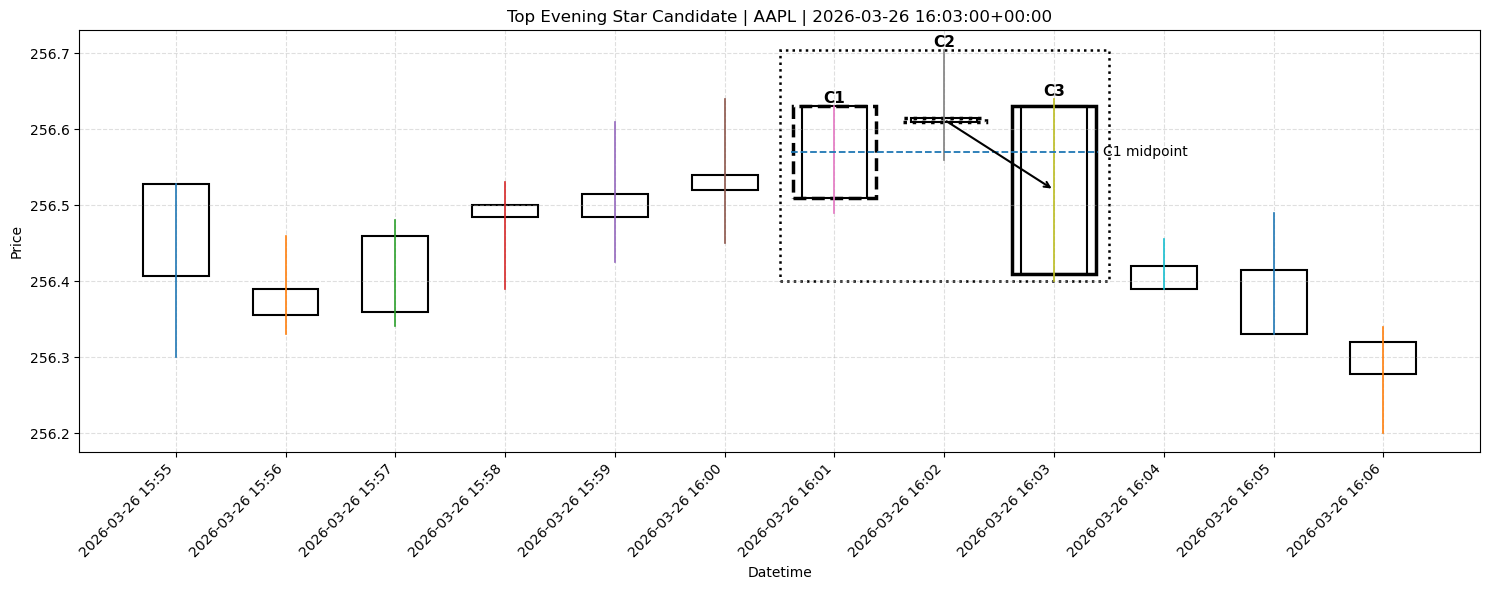

In [108]:
plot_evening_star_window(
    df_plot=plot_df,
    c1_idx=local_c1_idx,
    c2_idx=local_c2_idx,
    c3_idx=local_c3_idx,
    title=f"Top Evening Star Candidate | {top_ticker} | {top_time}",
)

Spining Top

In [109]:
from stock_analysis.candlestick_patterns.Spinning_Top_Candlestick import SpinningTopCandlestickPattern
from stock_analysis.tools.candlestick_utils import (
    add_candlestick_features,
    safe_ratio,
)

In [110]:
def explain_spinning_top_candle(df_window: pd.DataFrame) -> dict:
    df_feat = add_candlestick_features(df_window)
    c = df_feat.iloc[-1]

    body = c["body"]
    range_ = c["range"]
    upper_wick = c["upper_wick"]
    lower_wick = c["lower_wick"]

    body_ratio = safe_ratio(body, range_)
    wick_presence_ratio = safe_ratio(upper_wick + lower_wick, range_)
    wick_balance_ratio = safe_ratio(
        min(upper_wick, lower_wick),
        max(upper_wick, lower_wick),
    )

    shape_ok = (
        range_ > 0
        and body_ratio >= 0.05
        and body_ratio <= 0.3
        and upper_wick > 0
        and lower_wick > 0
        and wick_presence_ratio >= 0.55
        and wick_balance_ratio >= 0.35
    )

    return {
        "Datetime": c["Datetime"] if "Datetime" in c.index else None,
        "Open": c["Open"],
        "High": c["High"],
        "Low": c["Low"],
        "Close": c["Close"],
        "direction": c["direction"],
        "body": body,
        "range": range_,
        "upper_wick": upper_wick,
        "lower_wick": lower_wick,
        "body_ratio": body_ratio,
        "wick_presence_ratio": wick_presence_ratio,
        "wick_balance_ratio": wick_balance_ratio,
        "shape_ok": shape_ok,
    }

In [111]:
def plot_spinning_top_window(
    df_plot: pd.DataFrame,
    highlight_idx: int,
    title: str = "Spinning Top Pattern",
):
    df_plot = df_plot.copy().reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(df_plot))
    candle_width = 0.6

    # 1. draw all candlesticks
    for i, row in df_plot.iterrows():
        open_ = row["Open"]
        high_ = row["High"]
        low_ = row["Low"]
        close_ = row["Close"]

        ax.plot([i, i], [low_, high_], linewidth=1.2)

        body_low = min(open_, close_)
        body_height = abs(close_ - open_)

        rect = Rectangle(
            (i - candle_width / 2, body_low),
            candle_width,
            max(body_height, 0.001),
            fill=False,
            linewidth=1.5
        )
        ax.add_patch(rect)

    # 2. highlight target candle
    row = df_plot.iloc[highlight_idx]
    body_low = min(row["Open"], row["Close"])
    body_high = max(row["Open"], row["Close"])

    highlight_rect = Rectangle(
        (highlight_idx - candle_width / 2 - 0.08, body_low),
        candle_width + 0.16,
        max(body_high - body_low, 0.001),
        fill=False,
        linewidth=2.5,
        linestyle="--"
    )
    ax.add_patch(highlight_rect)

    ax.text(
        highlight_idx,
        row["High"],
        "Spinning Top",
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="bottom"
    )

    # 3. outer frame around full candle
    full_box = Rectangle(
        (highlight_idx - candle_width / 2 - 0.15, row["Low"]),
        candle_width + 0.3,
        row["High"] - row["Low"],
        fill=False,
        linewidth=1.8,
        linestyle=":"
    )
    ax.add_patch(full_box)

    # 4. axes / labels
    ax.set_xticks(x)
    ax.set_xticklabels(
        [str(pd.to_datetime(dt))[:16] for dt in df_plot["Datetime"]],
        rotation=45,
        ha="right"
    )

    ax.set_title(title)
    ax.set_xlabel("Datetime")
    ax.set_ylabel("Price")
    ax.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

In [112]:
pattern = SpinningTopCandlestickPattern()
window_size = 1

spinning_top_results = scan_all_candlestick_patterns(
    df_all=df_long,
    pattern=pattern,
    window_size=window_size,
)

print("Total detected Spinning Top patterns:", len(spinning_top_results))

if spinning_top_results.empty:
    print("No Spinning Top patterns detected.")
else:
    print("\nCounts by ticker:")
    print(spinning_top_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        spinning_top_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 1
Scanning tickers: ['AAPL', 'AMZN', 'MSFT', 'NVDA', 'TSLA']
Total detected Spinning Top patterns: 1475

Counts by ticker:
Ticker
NVDA    322
TSLA    315
MSFT    309
AMZN    275
AAPL    254
Name: count, dtype: int64

Top 20 by confidence:


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
10,AAPL,2026-03-26 14:42:00+00:00,SpinningTopCandlestickPattern,candlestick,90.0,72,72
12,AAPL,2026-03-26 14:44:00+00:00,SpinningTopCandlestickPattern,candlestick,90.0,74,74
56,AAPL,2026-03-27 14:29:00+00:00,SpinningTopCandlestickPattern,candlestick,90.0,449,449
60,AAPL,2026-03-27 14:59:00+00:00,SpinningTopCandlestickPattern,candlestick,90.0,479,479
78,AAPL,2026-03-27 17:33:00+00:00,SpinningTopCandlestickPattern,candlestick,90.0,631,631
114,AAPL,2026-03-30 16:32:00+00:00,SpinningTopCandlestickPattern,candlestick,90.0,960,960
121,AAPL,2026-03-30 17:33:00+00:00,SpinningTopCandlestickPattern,candlestick,90.0,1021,1021
145,AAPL,2026-03-31 14:42:00+00:00,SpinningTopCandlestickPattern,candlestick,90.0,1240,1240
185,AAPL,2026-04-01 14:35:00+00:00,SpinningTopCandlestickPattern,candlestick,90.0,1623,1623
238,AAPL,2026-04-02 17:20:00+00:00,SpinningTopCandlestickPattern,candlestick,90.0,2178,2178


In [113]:
if spinning_top_results.empty:
    print("No Spinning Top patterns found, cannot select top candidate.")
else:
    top_spinning_top = (
        spinning_top_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Spinning Top candidate:")
    print(top_spinning_top)

    top_ticker = top_spinning_top["Ticker"]
    top_event_idx = int(top_spinning_top["WindowEndIdx"])
    top_time = top_spinning_top["Datetime"]

    print("\nSelected ticker:", top_ticker)
    print("Event index:", top_event_idx)
    print("Event time:", top_time)

Top Spinning Top candidate:
Ticker                                     AAPL
Datetime              2026-03-26 14:42:00+00:00
Pattern           SpinningTopCandlestickPattern
Category                            candlestick
Confidence                                 90.0
WindowStartIdx                               72
WindowEndIdx                                 72
Name: 10, dtype: object

Selected ticker: AAPL
Event index: 72
Event time: 2026-03-26 14:42:00+00:00


In [114]:
plot_df, local_event_idx = extract_pattern_context(
    df_all=df_long,
    ticker=top_ticker,
    event_idx=top_event_idx,
    left_context=8,
    right_context=3,
)

print("Plot window shape:", plot_df.shape)
display(plot_df.head())
display(plot_df.tail())

Plot window shape: (12, 6)


Price,Datetime,Ticker,Open,High,Low,Close
0,2026-03-26 14:34:00+00:00,AAPL,255.909302,256.029999,255.830002,256.010895
1,2026-03-26 14:35:00+00:00,AAPL,256.040009,256.119995,255.940002,255.940002
2,2026-03-26 14:36:00+00:00,AAPL,255.940002,256.125000,255.899994,255.970901
3,2026-03-26 14:37:00+00:00,AAPL,255.955002,256.000000,255.845001,255.919998
4,2026-03-26 14:38:00+00:00,AAPL,255.949997,256.169891,255.869995,256.059998


Price,Datetime,Ticker,Open,High,Low,Close
7,2026-03-26 14:41:00+00:00,AAPL,256.309998,256.410004,255.850006,256.369995
8,2026-03-26 14:42:00+00:00,AAPL,256.369995,256.569397,256.220001,256.400085
9,2026-03-26 14:43:00+00:00,AAPL,256.404999,256.539886,256.320007,256.459991
10,2026-03-26 14:44:00+00:00,AAPL,256.440002,256.579987,256.279999,256.410004
11,2026-03-26 14:45:00+00:00,AAPL,256.390015,256.420013,256.031494,256.054993


In [115]:
plot_df, local_event_idx = extract_pattern_context(
    df_all=df_long,
    ticker=top_ticker,
    event_idx=top_event_idx,
    left_context=8,
    right_context=3,
)

print("Plot window shape:", plot_df.shape)
display(plot_df.head())
display(plot_df.tail())

Plot window shape: (12, 6)


Price,Datetime,Ticker,Open,High,Low,Close
0,2026-03-26 14:34:00+00:00,AAPL,255.909302,256.029999,255.830002,256.010895
1,2026-03-26 14:35:00+00:00,AAPL,256.040009,256.119995,255.940002,255.940002
2,2026-03-26 14:36:00+00:00,AAPL,255.940002,256.125000,255.899994,255.970901
3,2026-03-26 14:37:00+00:00,AAPL,255.955002,256.000000,255.845001,255.919998
4,2026-03-26 14:38:00+00:00,AAPL,255.949997,256.169891,255.869995,256.059998


Price,Datetime,Ticker,Open,High,Low,Close
7,2026-03-26 14:41:00+00:00,AAPL,256.309998,256.410004,255.850006,256.369995
8,2026-03-26 14:42:00+00:00,AAPL,256.369995,256.569397,256.220001,256.400085
9,2026-03-26 14:43:00+00:00,AAPL,256.404999,256.539886,256.320007,256.459991
10,2026-03-26 14:44:00+00:00,AAPL,256.440002,256.579987,256.279999,256.410004
11,2026-03-26 14:45:00+00:00,AAPL,256.390015,256.420013,256.031494,256.054993


In [116]:
target_candle_df = plot_df.iloc[[local_event_idx]].copy().reset_index(drop=True)

print("Target Spinning Top candle:")
display(target_candle_df)

Target Spinning Top candle:


Price,Datetime,Ticker,Open,High,Low,Close
0,2026-03-26 14:42:00+00:00,AAPL,256.369995,256.569397,256.220001,256.400085


In [117]:
spinning_top_explanation = explain_spinning_top_candle(target_candle_df)

print("Extracted Spinning Top explanation:")
for k, v in spinning_top_explanation.items():
    print(f"{k}: {v}")

Extracted Spinning Top explanation:
Datetime: 2026-03-26 14:42:00+00:00
Open: 256.3699951171875
High: 256.56939697265625
Low: 256.2200012207031
Close: 256.40008544921875
direction: bullish
body: 0.03009033203125
range: 0.349395751953125
upper_wick: 0.1693115234375
lower_wick: 0.149993896484375
body_ratio: 0.08612105860773867
wick_presence_ratio: 0.9138789413922613
wick_balance_ratio: 0.8859048305695746
shape_ok: True


In [118]:
spinning_top_explanation_df = pd.DataFrame([spinning_top_explanation])
display(spinning_top_explanation_df)

,Datetime,Open,High,Low,Close,direction,body,range,upper_wick,lower_wick,body_ratio,wick_presence_ratio,wick_balance_ratio,shape_ok
0,2026-03-26 14:42:00+00:00,256.369995,256.569397,256.220001,256.400085,bullish,0.03009,0.349396,0.169312,0.149994,0.086121,0.913879,0.885905,True


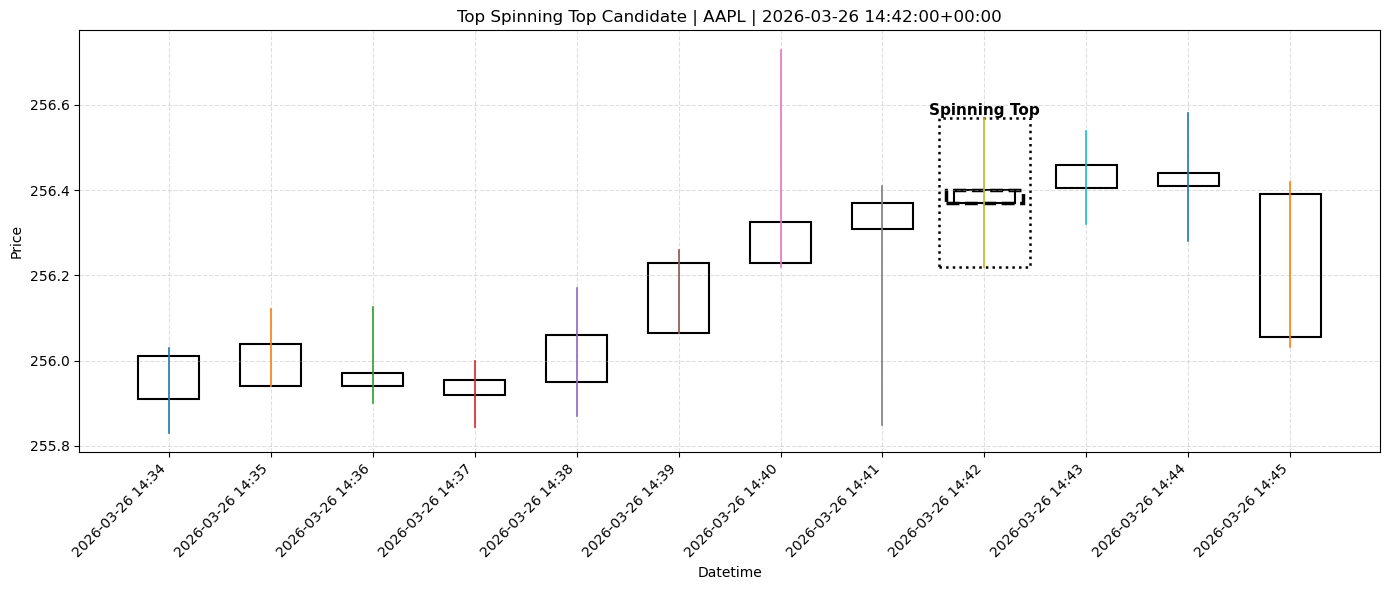

In [119]:
plot_spinning_top_window(
    df_plot=plot_df,
    highlight_idx=local_event_idx,
    title=f"Top Spinning Top Candidate | {top_ticker} | {top_time}",
)